## 0. Imports & Config

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import yaml
import pyarrow
from sklearn.preprocessing import RobustScaler

# Paths
YAML_PATH  = Path("/home/bri/pymol/EDA/static/metric_directions.yaml")
OUTPUT_DIR = Path("/home/bri/pymol/EDA/static/rankings")
OUTPUT_DIR.mkdir(exist_ok=True)

# Color palette
colors_map = {
    'Binder':         '#2ecc71',
    'Non-Binder':     '#67e7dd',
    'Target Shuffle': '#273397',
    'germinal':       '#2ecc71',
    'mcmahon':        '#d6a439',
    'snir_ab':        '#1f3397',
    'harvey':         '#971f6f',
}

# Model list 
models = [
    'af3', 'cf', 'esmfold',
    'chai_constrained', 'chai_unconstrained',
    'boltz_free', 'boltz_template',
]



## 1. Data Loading & Merging

In [15]:
germinal = pd.read_csv("/home/bri/pymol/EDA/static/germinal_outputs/scores_df_extended_with_chai.csv")
mcmahon  = pd.read_csv("/home/bri/pymol/EDA/static/mcmahon_outputs/scores_df_extended_with_chai.csv")
snir     = pd.read_csv("/home/bri/pymol/EDA/static/snir_outputs/scores_df_extended_with_chai.csv")
harvey   = pd.read_csv("/home/bri/pymol/EDA/static/harvey_outputs/scores_df_extended_with_chai.csv")

print(f"Germinal:\n{germinal['binder'].value_counts()}")
print(f"McMahon:\n{mcmahon['binder'].value_counts()}")
print(f"Snir:\n{snir['binder'].value_counts()}")
print(f"Harvey:\n{harvey['binder'].value_counts()}")

combine = (germinal, mcmahon, snir, harvey)
df = pd.concat(combine).reset_index(drop=True)
df.to_csv(OUTPUT_DIR / 'scores_df_merged_final.csv', index=False)
print('Saved scores_df_merged_final.csv')

Germinal:
binder
0    456
1     24
Name: count, dtype: int64
McMahon:
binder
0    23
1    17
Name: count, dtype: int64
Snir:
binder
0    32
1     3
Name: count, dtype: int64
Harvey:
binder
0    29
1    27
Name: count, dtype: int64
Saved scores_df_merged_final.csv


## 2. Preprocessing

In [16]:
# Drop ranking-score columns that are not needed downstream
cols_to_drop = [
    'af3_rank', 'af3_ranking_score', 'af3_rank0_masif',
    'cf_rank', 'cf_rank0_masif',
]
scores_df = df.drop(columns=cols_to_drop)

# Add human-readable binder_type label BEFORE scaling so it is
# always present in every downstream DataFrame.
def categorize_row(row):
    if row['binder'] == 1:
        return 'Binder'
    elif row['type'] == 'original':    # binder == 0
        return 'Non-Binder'
    else:                              # binder == 0, type == target_shuffle
        return 'Target Shuffle'

scores_df = scores_df.copy()
scores_df['binder_type'] = scores_df.apply(categorize_row, axis=1)

# DataFrame 1 – preprocessed, original scale
scores_df.head()

,source,type,binder,KD[M],sample,af3_pae,af3_plddt,af3_interface_dG,af3_interface_dG_SASA_ratio,af3_ipae,...,boltz_template_ipsae,boltz_template_pdockq,boltz_template_pdockq2,boltz_template_lis,chai_unconstrained_per_chain_ptm,chai_constrained_per_chain_ptm,chai_unconstrained_per_chain_pair_iptm,chai_constrained_per_chain_pair_iptm,EC50[M],binder_type
0,germinal,original,0,NaN,nb_s413501_mpnn_3_PDL1,6.108293,86.742610,16.79,0.93,2.044286,...,0.286417,0.3117,0.2812,0.3347,0.889467,0.931936,0.443412,0.806765,NaN,Non-Binder
1,germinal,original,0,NaN,nb_s80903_mpnn_4_PDL1,5.704870,87.377710,35.37,2.03,2.497436,...,0.615900,0.3215,0.4823,0.5713,0.889938,0.925439,0.650884,0.683231,NaN,Non-Binder
2,germinal,original,0,NaN,nb_s185784_mpnn_4_PDL1,5.882517,87.466883,68.68,4.47,3.201563,...,0.410030,0.2974,0.3102,0.4039,0.926919,0.874951,0.718872,0.306330,NaN,Non-Binder
3,germinal,original,0,NaN,nb_s465730_mpnn_4_PDL1,6.592750,85.815865,132.43,7.57,3.376923,...,0.683534,0.3291,0.5252,0.5998,0.881173,0.895348,0.678524,0.733525,NaN,Non-Binder
4,germinal,original,0,NaN,nb_s892360_mpnn_4_PDL1,6.833474,86.163597,81.72,4.71,3.086486,...,0.783194,0.4001,0.7099,0.6743,0.884861,0.892371,0.254212,0.389953,NaN,Non-Binder


In [17]:
# Define meta / numeric column sets — single authoritative source of truth.
# meta_cols is listed first so numeric_cols is derived from it (not the
# other way round). KD[M] / EC50[M] are excluded from metrics.
meta_cols    = ['sample', 'binder', 'source', 'type', 'iteration', 'binder_type']
exclude_cols = ['KD[M]', 'EC50[M]']

scores_df["KD[M]"] = pd.to_numeric(scores_df["KD[M]"], errors="coerce")

numeric_cols = [
    c for c in scores_df.columns
    if c not in meta_cols and c not in exclude_cols
]

print(f"{len(numeric_cols)} numeric metric columns selected")
numeric_cols

80 numeric metric columns selected


['af3_pae',
 'af3_plddt',
 'af3_interface_dG',
 'af3_interface_dG_SASA_ratio',
 'af3_ipae',
 'af3_iplddt',
 'af3_ipsae',
 'af3_pdockq',
 'af3_pdockq2',
 'af3_lis',
 'af3_iptm',
 'af3_ptm',
 'af3_pyros_binder_score',
 'cf_af3_rmsd',
 'cf_pae',
 'cf_plddt',
 'cf_interface_dG',
 'cf_interface_dG_SASA_ratio',
 'cf_ipae',
 'cf_iplddt',
 'cf_ipsae',
 'cf_pdockq',
 'cf_pdockq2',
 'cf_lis',
 'cf_iptm',
 'cf_ptm',
 'cf_pyros_binder_score',
 'pred_ilddt',
 'pred_lddt',
 'esmfold_ipae',
 'esmfold_iplddt',
 'esmfold_plddt',
 'esmfold_pae',
 'esmfold_ptm',
 'chai_unconstrained_score',
 'chai_constrained_score',
 'chai_unconstrained_aggregate_score',
 'chai_unconstrained_ptm',
 'chai_unconstrained_iptm',
 'chai_unconstrained_interface_iptm',
 'chai_unconstrained_ipsae',
 'chai_unconstrained_pdockq',
 'chai_unconstrained_pdockq2',
 'chai_unconstrained_lis',
 'chai_constrained_aggregate_score',
 'chai_constrained_ptm',
 'chai_constrained_iptm',
 'chai_constrained_interface_iptm',
 'chai_constrained_ip

In [18]:
missing_report = (
    scores_df[numeric_cols]
    .isna()
    .sum()
    .sort_values(ascending=False)
)
missing_report

esmfold_iplddt                            136
esmfold_ipae                              136
chai_constrained_ipsae                      2
chai_constrained_pdockq                     2
chai_constrained_pdockq2                    2
                                         ... 
boltz_template_lis                          0
chai_unconstrained_per_chain_ptm            0
chai_constrained_per_chain_ptm              0
chai_unconstrained_per_chain_pair_iptm      0
chai_constrained_per_chain_pair_iptm        0
Length: 80, dtype: int64

## identify outliers

In [19]:
numeric_df = scores_df.select_dtypes(include=["number"])
Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1

outliers = (numeric_df < (Q1 - 1.5 * IQR)) | (numeric_df > (Q3 + 1.5 * IQR))
outlier_counts = outliers.sum()
outlier_counts.sort_values(ascending=False)

chai_constrained_per_chain_ptm          140
chai_unconstrained_per_chain_ptm        138
boltz_free_plddt                        111
chai_unconstrained_pdockq2              107
boltz_free_confidence_score             104
                                       ... 
boltz_template_iplddt                     0
boltz_template_ipsae                      0
boltz_template_pdockq2                    0
boltz_template_lis                        0
chai_constrained_per_chain_pair_iptm      0
Length: 83, dtype: int64

In [20]:
z_scores = (numeric_df - numeric_df.mean()) / numeric_df.std()
outliers = z_scores.abs() > 3
outlier_counts = outliers.sum()
outlier_counts.sort_values(ascending=False)

af3_ptm                                   35
af3_pyros_binder_score                    20
boltz_free_pdockq2                        16
cf_ipae                                   15
af3_ipae                                  12
                                          ..
chai_unconstrained_per_chain_ptm           0
chai_constrained_per_chain_ptm             0
chai_unconstrained_per_chain_pair_iptm     0
chai_constrained_per_chain_pair_iptm       0
EC50[M]                                    0
Length: 83, dtype: int64

In [21]:
def robust_outliers(df):
    Q1 = df.quantile(0.25)
    Q3 = df.quantile(0.75)
    IQR = Q3 - Q1
    return (df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))

In [22]:
median = numeric_df.median()
mad = (numeric_df - median).abs().median()

robust_z = (numeric_df - median) / mad
outliers = robust_z.abs() > 3.5

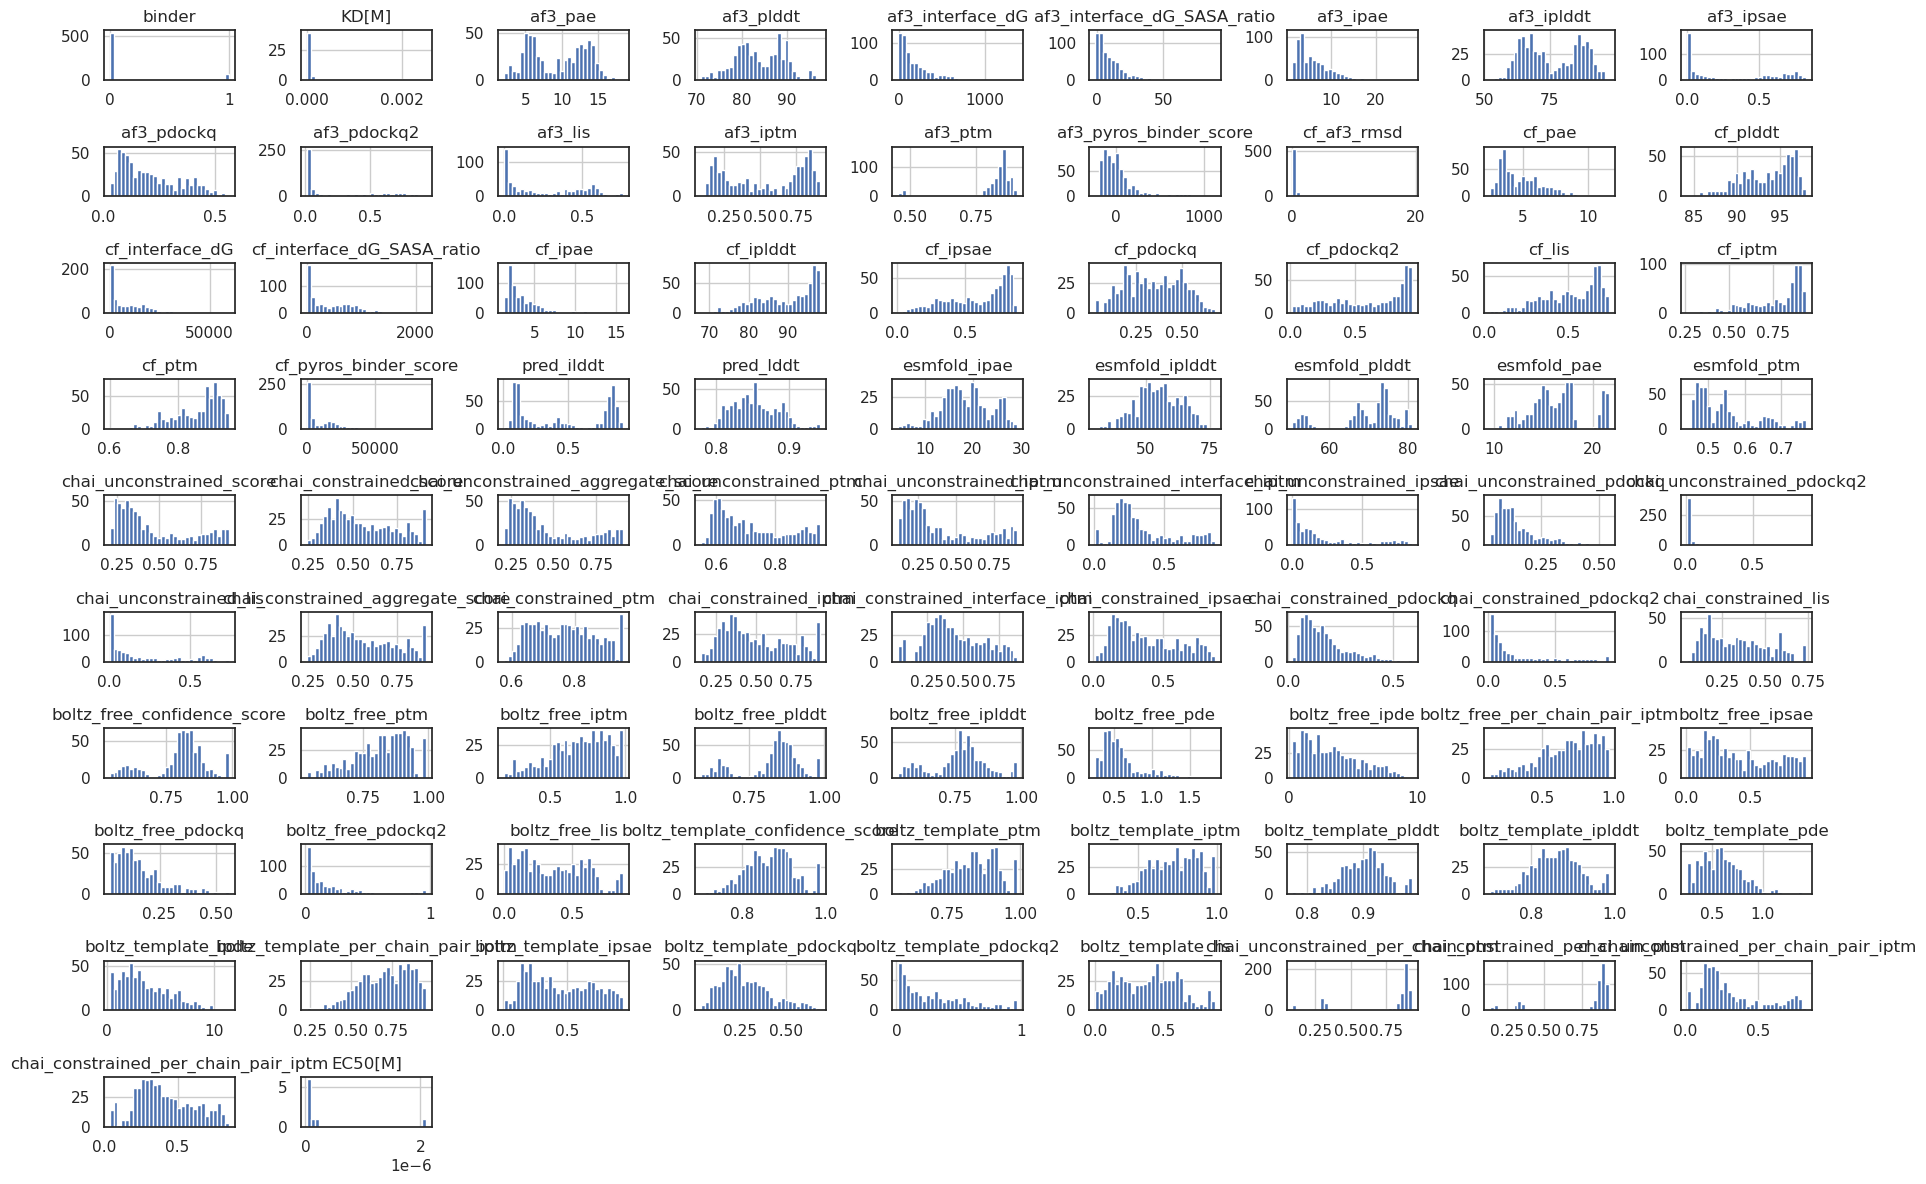

In [23]:
import matplotlib.pyplot as plt

numeric_df = scores_df.select_dtypes(include=["number"])

numeric_df.hist(figsize=(18, 12), bins=30)
plt.tight_layout()
plt.show()

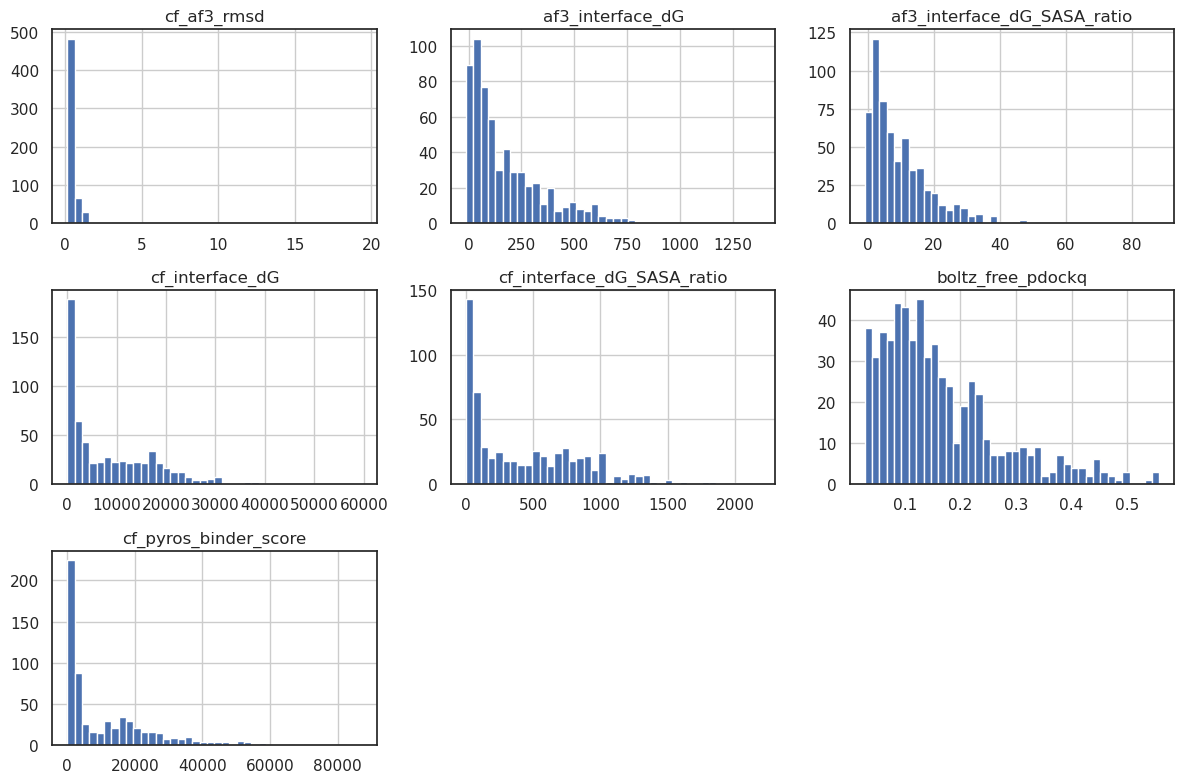

In [24]:
cols = [
    "cf_af3_rmsd",
    "af3_interface_dG",
    "af3_interface_dG_SASA_ratio",
    "cf_interface_dG",
    "cf_interface_dG_SASA_ratio",
    "boltz_free_pdockq",
    "cf_pyros_binder_score"
]

scores_df[cols].hist(bins=40, figsize=(12, 8))
plt.tight_layout()
plt.show()

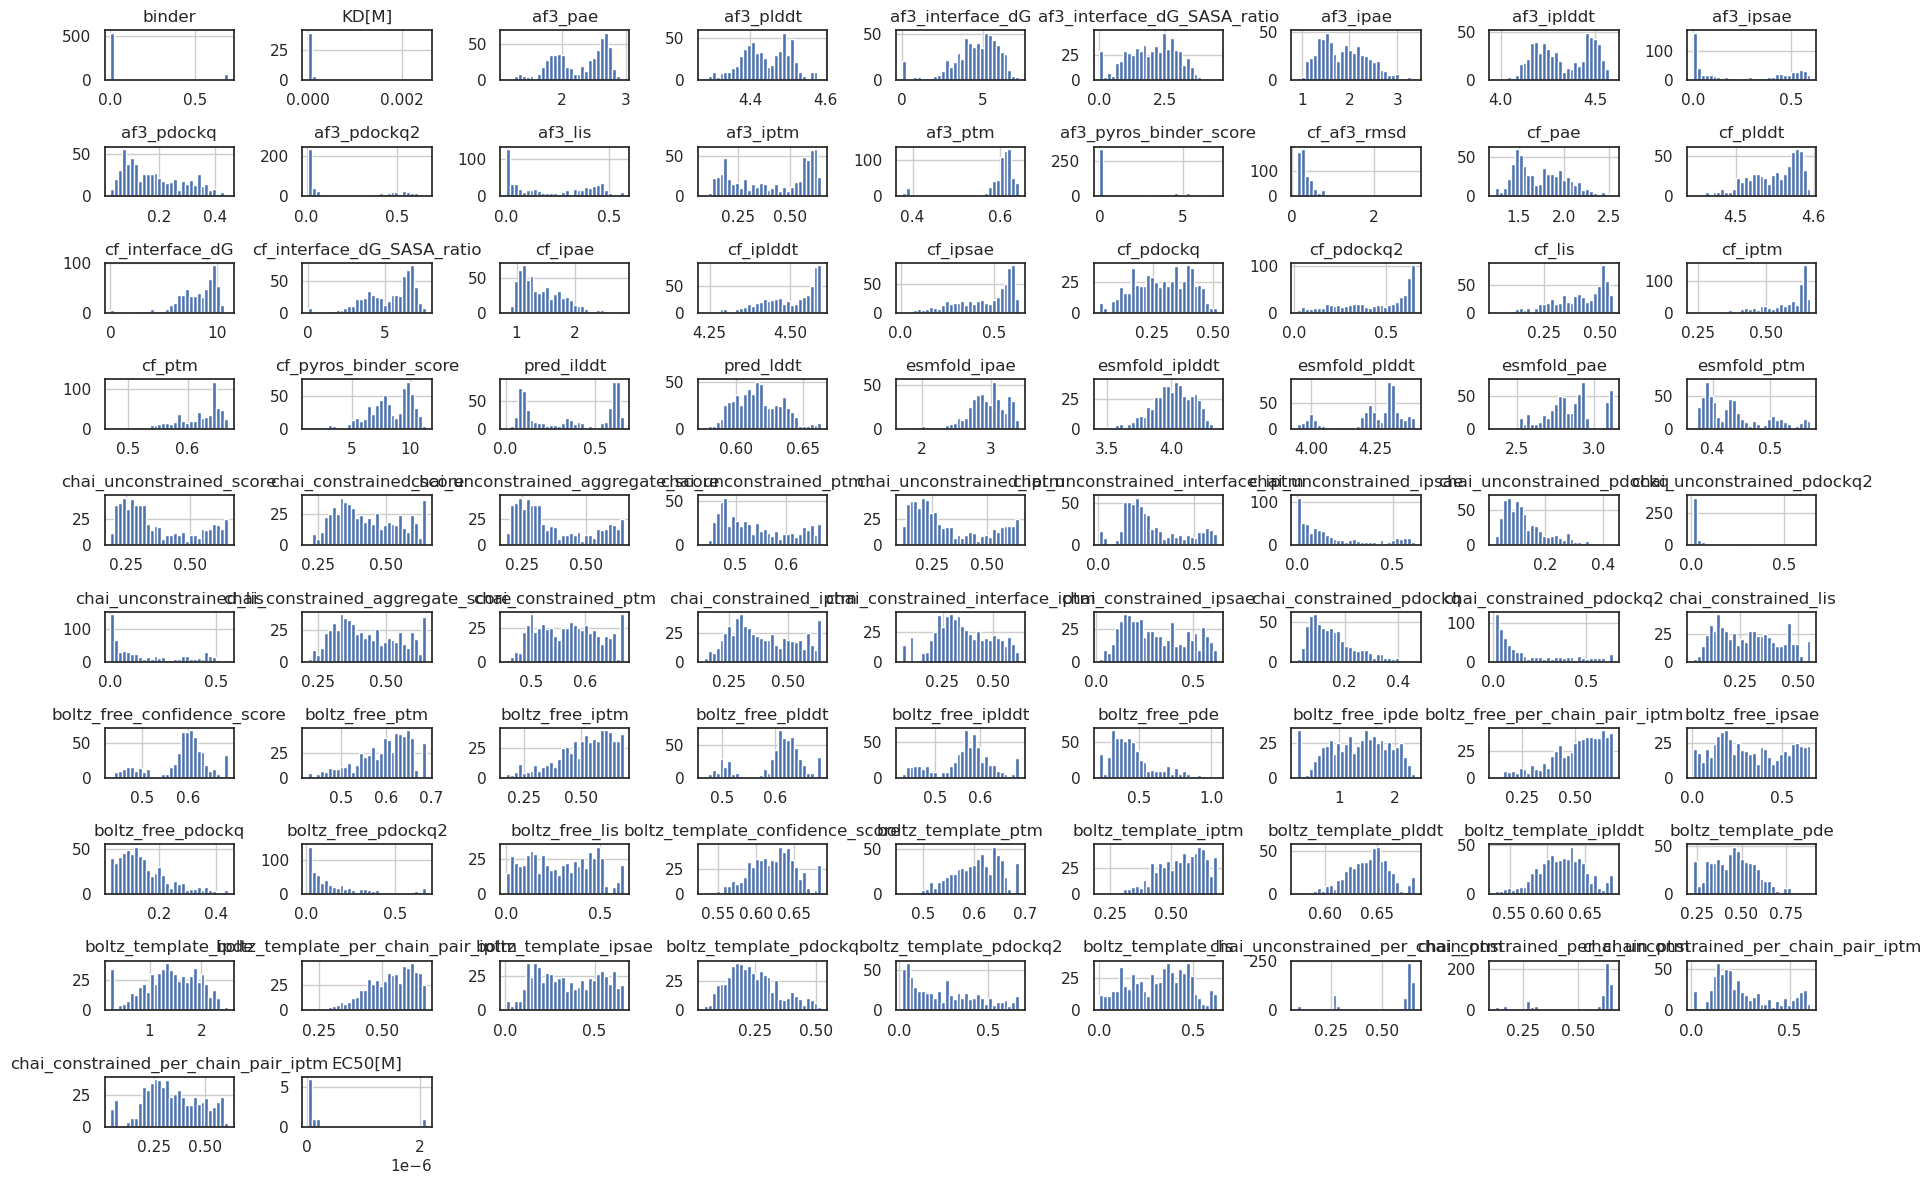

In [25]:
import numpy as np

log_df = np.log1p(numeric_df.clip(lower=0))
log_df.hist(figsize=(18, 12), bins=30)
plt.tight_layout()
plt.show()

In [26]:
df = scores_df.copy()
num = df.select_dtypes(include=["number"])

In [27]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
num_scaled = pd.DataFrame(
    scaler.fit_transform(num),
    columns=num.columns,
    index=num.index
)

In [28]:
good_cols = [
    "af3_plddt",
    "af3_ptm",
    "cf_plddt",
    "boltz_free_ptm",
    "af3_pdockq",
    "cf_pdockq",
    "boltz_free_pdockq"
]

bad_cols = [
    "af3_interface_dG",
    "cf_interface_dG",
    "af3_ipae",
    "cf_ipae"
]

score = pd.Series(0, index=num.index)

# good metrics contribute positively
score += num_scaled[good_cols].mean(axis=1)

# bad metrics subtract (invert)
score -= num_scaled[bad_cols].mean(axis=1)

In [29]:
threshold = score.median()  # or top 30%

labels = (score > threshold).astype(int)
df["prediction_quality"] = labels

In [30]:
df.groupby("prediction_quality")[good_cols + bad_cols].mean()

,af3_plddt,af3_ptm,cf_plddt,boltz_free_ptm,af3_pdockq,cf_pdockq,boltz_free_pdockq,af3_interface_dG,cf_interface_dG,af3_ipae,cf_ipae
prediction_quality,,,,,,,,,,,
0,80.775025,0.788938,91.511654,0.808955,0.126052,0.269643,0.156041,301.344461,8488.287010,8.918780,4.628545
1,87.064963,0.850549,95.490270,0.822139,0.294824,0.419287,0.168522,68.903934,8624.935705,3.954381,2.311588


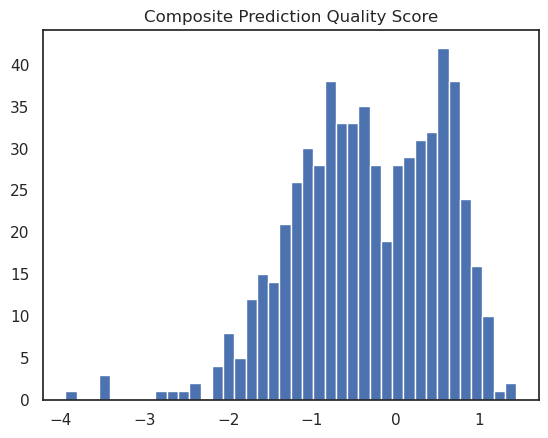

In [31]:
import matplotlib.pyplot as plt

plt.hist(score, bins=40)
plt.title("Composite Prediction Quality Score")
plt.show()

## 3. Transformation

In [32]:
# DataFrame 2 – RobustScaler (try standard / quantile if needed)
scaler = RobustScaler()
scores_df_scaled = scores_df.copy()
scores_df_scaled[numeric_cols] = scaler.fit_transform(scores_df[numeric_cols])

scores_df_scaled.head()

,source,type,binder,KD[M],sample,af3_pae,af3_plddt,af3_interface_dG,af3_interface_dG_SASA_ratio,af3_ipae,...,boltz_template_ipsae,boltz_template_pdockq,boltz_template_pdockq2,boltz_template_lis,chai_unconstrained_per_chain_ptm,chai_constrained_per_chain_ptm,chai_unconstrained_per_chain_pair_iptm,chai_constrained_per_chain_pair_iptm,EC50[M],binder_type
0,germinal,original,0,NaN,nb_s413501_mpnn_3_PDL1,-0.465303,0.386162,-0.432451,-0.526882,-0.664374,...,-0.256786,0.322108,0.053275,-0.187133,0.099640,0.577533,0.794792,1.455071,NaN,Non-Binder
1,germinal,original,0,NaN,nb_s80903_mpnn_4_PDL1,-0.520803,0.460954,-0.347935,-0.432258,-0.571457,...,0.465532,0.375339,0.540259,0.474685,0.104102,0.509888,1.576059,1.033933,NaN,Non-Binder
2,germinal,original,0,NaN,nb_s185784_mpnn_4_PDL1,-0.496364,0.471455,-0.196416,-0.222366,-0.427077,...,0.014208,0.244432,0.123502,0.006434,0.454902,-0.015745,1.832077,-0.250956,NaN,Non-Binder
3,germinal,original,0,NaN,nb_s465730_mpnn_4_PDL1,-0.398655,0.277025,0.093568,0.044301,-0.391119,...,0.613804,0.416621,0.644146,0.554406,0.020964,0.196613,1.680140,1.205389,NaN,Non-Binder
4,germinal,original,0,NaN,nb_s892360_mpnn_4_PDL1,-0.365538,0.317975,-0.137100,-0.201720,-0.450673,...,0.832287,0.802281,1.091415,0.762797,0.055947,0.165615,0.082332,0.034124,NaN,Non-Binder


In [33]:
# Load metric directionality from YAML
# +1 → higher is better   -1 → lower is better
if Path(YAML_PATH).exists():
    with open(YAML_PATH, 'r') as f:
        yaml_data = yaml.safe_load(f)
    raw_directions = {k: v['direction'] for k, v in yaml_data['metrics'].items()}
    # Sort longest-key-first so 'iptm' is checked before 'ptm'
    metric_directions = dict(
        sorted(raw_directions.items(), key=lambda x: len(x[0]), reverse=True)
    )
    print(f"Loaded {len(metric_directions)} metric directions from YAML.")
else:
    print(f"WARNING: YAML not found at {YAML_PATH}. Using default direction (+1).")
    metric_directions = {}


def get_direction(col_name):
    """Return +1 or -1 for a metric column.

    Uses suffix matching (col ends with '_<base>') to avoid 'ptm'
    accidentally matching 'iptm'.
    """
    for base_metric, direction in metric_directions.items():
        if col_name == base_metric or col_name.endswith(f'_{base_metric}'):
            return direction
    return 1  # default: higher is better


# DataFrame 3 – direction-aligned scaled values
# After this, a higher value always means a better prediction.
scores_df_aligned = scores_df_scaled.copy()
for col in numeric_cols:
    scores_df_aligned[col] = scores_df_aligned[col] * get_direction(col)

print("DataFrame 3 (direction-aligned, scaled) shape:", scores_df_aligned.shape)
scores_df_aligned.head()

Loaded 88 metric directions from YAML.
DataFrame 3 (direction-aligned, scaled) shape: (611, 87)


,source,type,binder,KD[M],sample,af3_pae,af3_plddt,af3_interface_dG,af3_interface_dG_SASA_ratio,af3_ipae,...,boltz_template_ipsae,boltz_template_pdockq,boltz_template_pdockq2,boltz_template_lis,chai_unconstrained_per_chain_ptm,chai_constrained_per_chain_ptm,chai_unconstrained_per_chain_pair_iptm,chai_constrained_per_chain_pair_iptm,EC50[M],binder_type
0,germinal,original,0,NaN,nb_s413501_mpnn_3_PDL1,0.465303,0.386162,0.432451,0.526882,0.664374,...,-0.256786,0.322108,0.053275,-0.187133,0.099640,0.577533,0.794792,1.455071,NaN,Non-Binder
1,germinal,original,0,NaN,nb_s80903_mpnn_4_PDL1,0.520803,0.460954,0.347935,0.432258,0.571457,...,0.465532,0.375339,0.540259,0.474685,0.104102,0.509888,1.576059,1.033933,NaN,Non-Binder
2,germinal,original,0,NaN,nb_s185784_mpnn_4_PDL1,0.496364,0.471455,0.196416,0.222366,0.427077,...,0.014208,0.244432,0.123502,0.006434,0.454902,-0.015745,1.832077,-0.250956,NaN,Non-Binder
3,germinal,original,0,NaN,nb_s465730_mpnn_4_PDL1,0.398655,0.277025,-0.093568,-0.044301,0.391119,...,0.613804,0.416621,0.644146,0.554406,0.020964,0.196613,1.680140,1.205389,NaN,Non-Binder
4,germinal,original,0,NaN,nb_s892360_mpnn_4_PDL1,0.365538,0.317975,0.137100,0.201720,0.450673,...,0.832287,0.802281,1.091415,0.762797,0.055947,0.165615,0.082332,0.034124,NaN,Non-Binder


In [34]:
# save dfs as parquet for downstream use 
scores_df.to_parquet("scores_raw.parquet")
scores_df_scaled.to_parquet("scores_scaled.parquet")
scores_df_aligned.to_parquet("scores_aligned.parquet")

In [35]:
# Melt scores_df_aligned (direction-aligned) to long format for plotting.
def parse_metric(metric):
    """Split 'model_metricname' into (model, metric_name)."""
    parts = metric.split('_')
    if metric.startswith('chai_') or metric.startswith('boltz_'):
        return '_'.join(parts[:2]), '_'.join(parts[2:])
    return parts[0], '_'.join(parts[1:])


long_scores_df = pd.melt(
    scores_df_aligned,
    id_vars=['sample', 'binder', 'binder_type', 'source', 'type'],
    value_vars=numeric_cols,
    var_name='metric',
    value_name='value',
)

long_scores_df[['model', 'metric_family']] = (
    long_scores_df['metric']
    .apply(parse_metric)
    .apply(pd.Series)
)

long_scores_df.to_csv(OUTPUT_DIR / 'long_scores_df.csv', index=False)
long_scores_df.tail()

,sample,binder,binder_type,source,type,metric,value,model,metric_family
48875,Sim4784_AA2AR,0,Target Shuffle,harvey,target_shuffle,chai_constrained_per_chain_pair_iptm,0.258122,chai_constrained,per_chain_pair_iptm
48876,Sim7252_AGTR1,0,Target Shuffle,harvey,target_shuffle,chai_constrained_per_chain_pair_iptm,0.396472,chai_constrained,per_chain_pair_iptm
48877,Sim8619_AGTR1,0,Target Shuffle,harvey,target_shuffle,chai_constrained_per_chain_pair_iptm,0.631201,chai_constrained,per_chain_pair_iptm
48878,Sim9877_AA2AR,0,Target Shuffle,harvey,target_shuffle,chai_constrained_per_chain_pair_iptm,0.210480,chai_constrained,per_chain_pair_iptm
48879,Nb60_ACM3,0,Target Shuffle,harvey,target_shuffle,chai_constrained_per_chain_pair_iptm,0.425340,chai_constrained,per_chain_pair_iptm


In [36]:
# Define metric groupings used for per-model and per-family plots
model_groups = {
    model: [c for c in numeric_cols if c.startswith(model)]
    for model in models
}

metric_families = {
    'plddt':   ['af3_plddt', 'cf_plddt', 'esmfold_plddt',
                'boltz_free_plddt', 'boltz_template_plddt'],
    'ptm':     ['af3_ptm', 'cf_ptm', 'esmfold_ptm',
                'chai_unconstrained_ptm', 'chai_constrained_ptm',
                'boltz_free_ptm', 'boltz_template_ptm'],
    'iptm':    ['af3_iptm', 'cf_iptm',
                'chai_unconstrained_iptm', 'chai_constrained_iptm',
                'boltz_free_iptm', 'boltz_template_iptm'],
    'pdockq2': ['af3_pdockq2', 'cf_pdockq2',
                'chai_unconstrained_pdockq2', 'chai_constrained_pdockq2',
                'boltz_free_pdockq2', 'boltz_template_pdockq2'],
}

## 4. Visualization

### 4a. Violin: Model Agreement per Metric Family

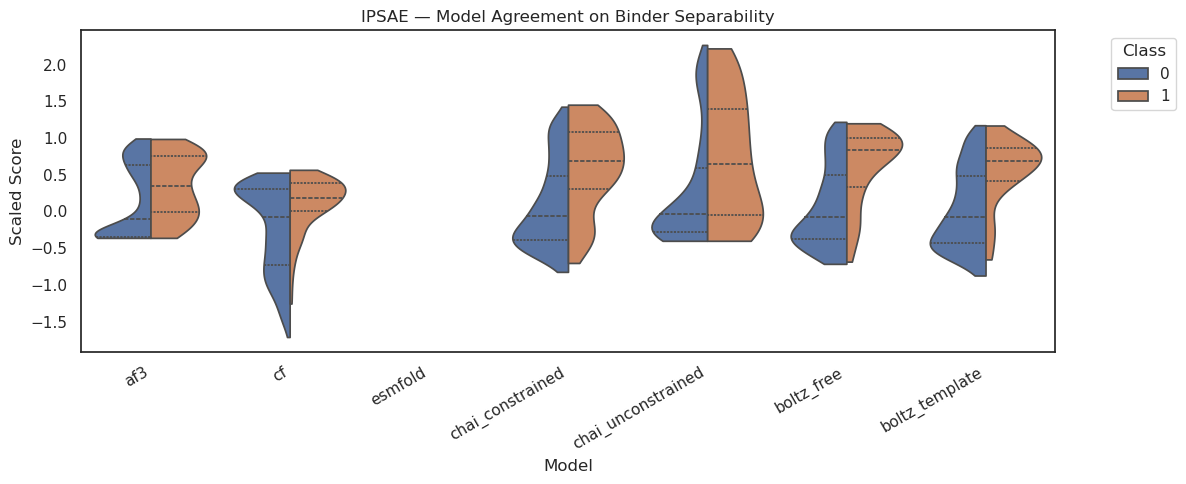

In [37]:
# NOTE: 'pde' is a placeholder family name — change 'family' to one of
# the keys in metric_families ('plddt', 'ptm', 'iptm', 'pdockq2').
for family in metric_families:
    family = 'ipsae'
df_f = long_scores_df[long_scores_df['metric_family'] == family].copy()

model_order = [
    'af3', 'cf', 'esmfold',
    'chai_constrained', 'chai_unconstrained',
    'boltz_free', 'boltz_template',
]

plt.figure(figsize=(12, 5))
sns.violinplot(
    data=df_f,
    x='model', y='value', hue='binder',
    order=model_order,
    split=True, inner='quartile', cut=0, density_norm='width',
)
plt.title(f"{family.upper()} — Model Agreement on Binder Separability")
plt.xlabel('Model')
plt.ylabel('Scaled Score')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Class', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f'{family}_model_agreement.png', dpi=200)
plt.show()

### 4b. Per-Model Separability Scatter (strip + box)

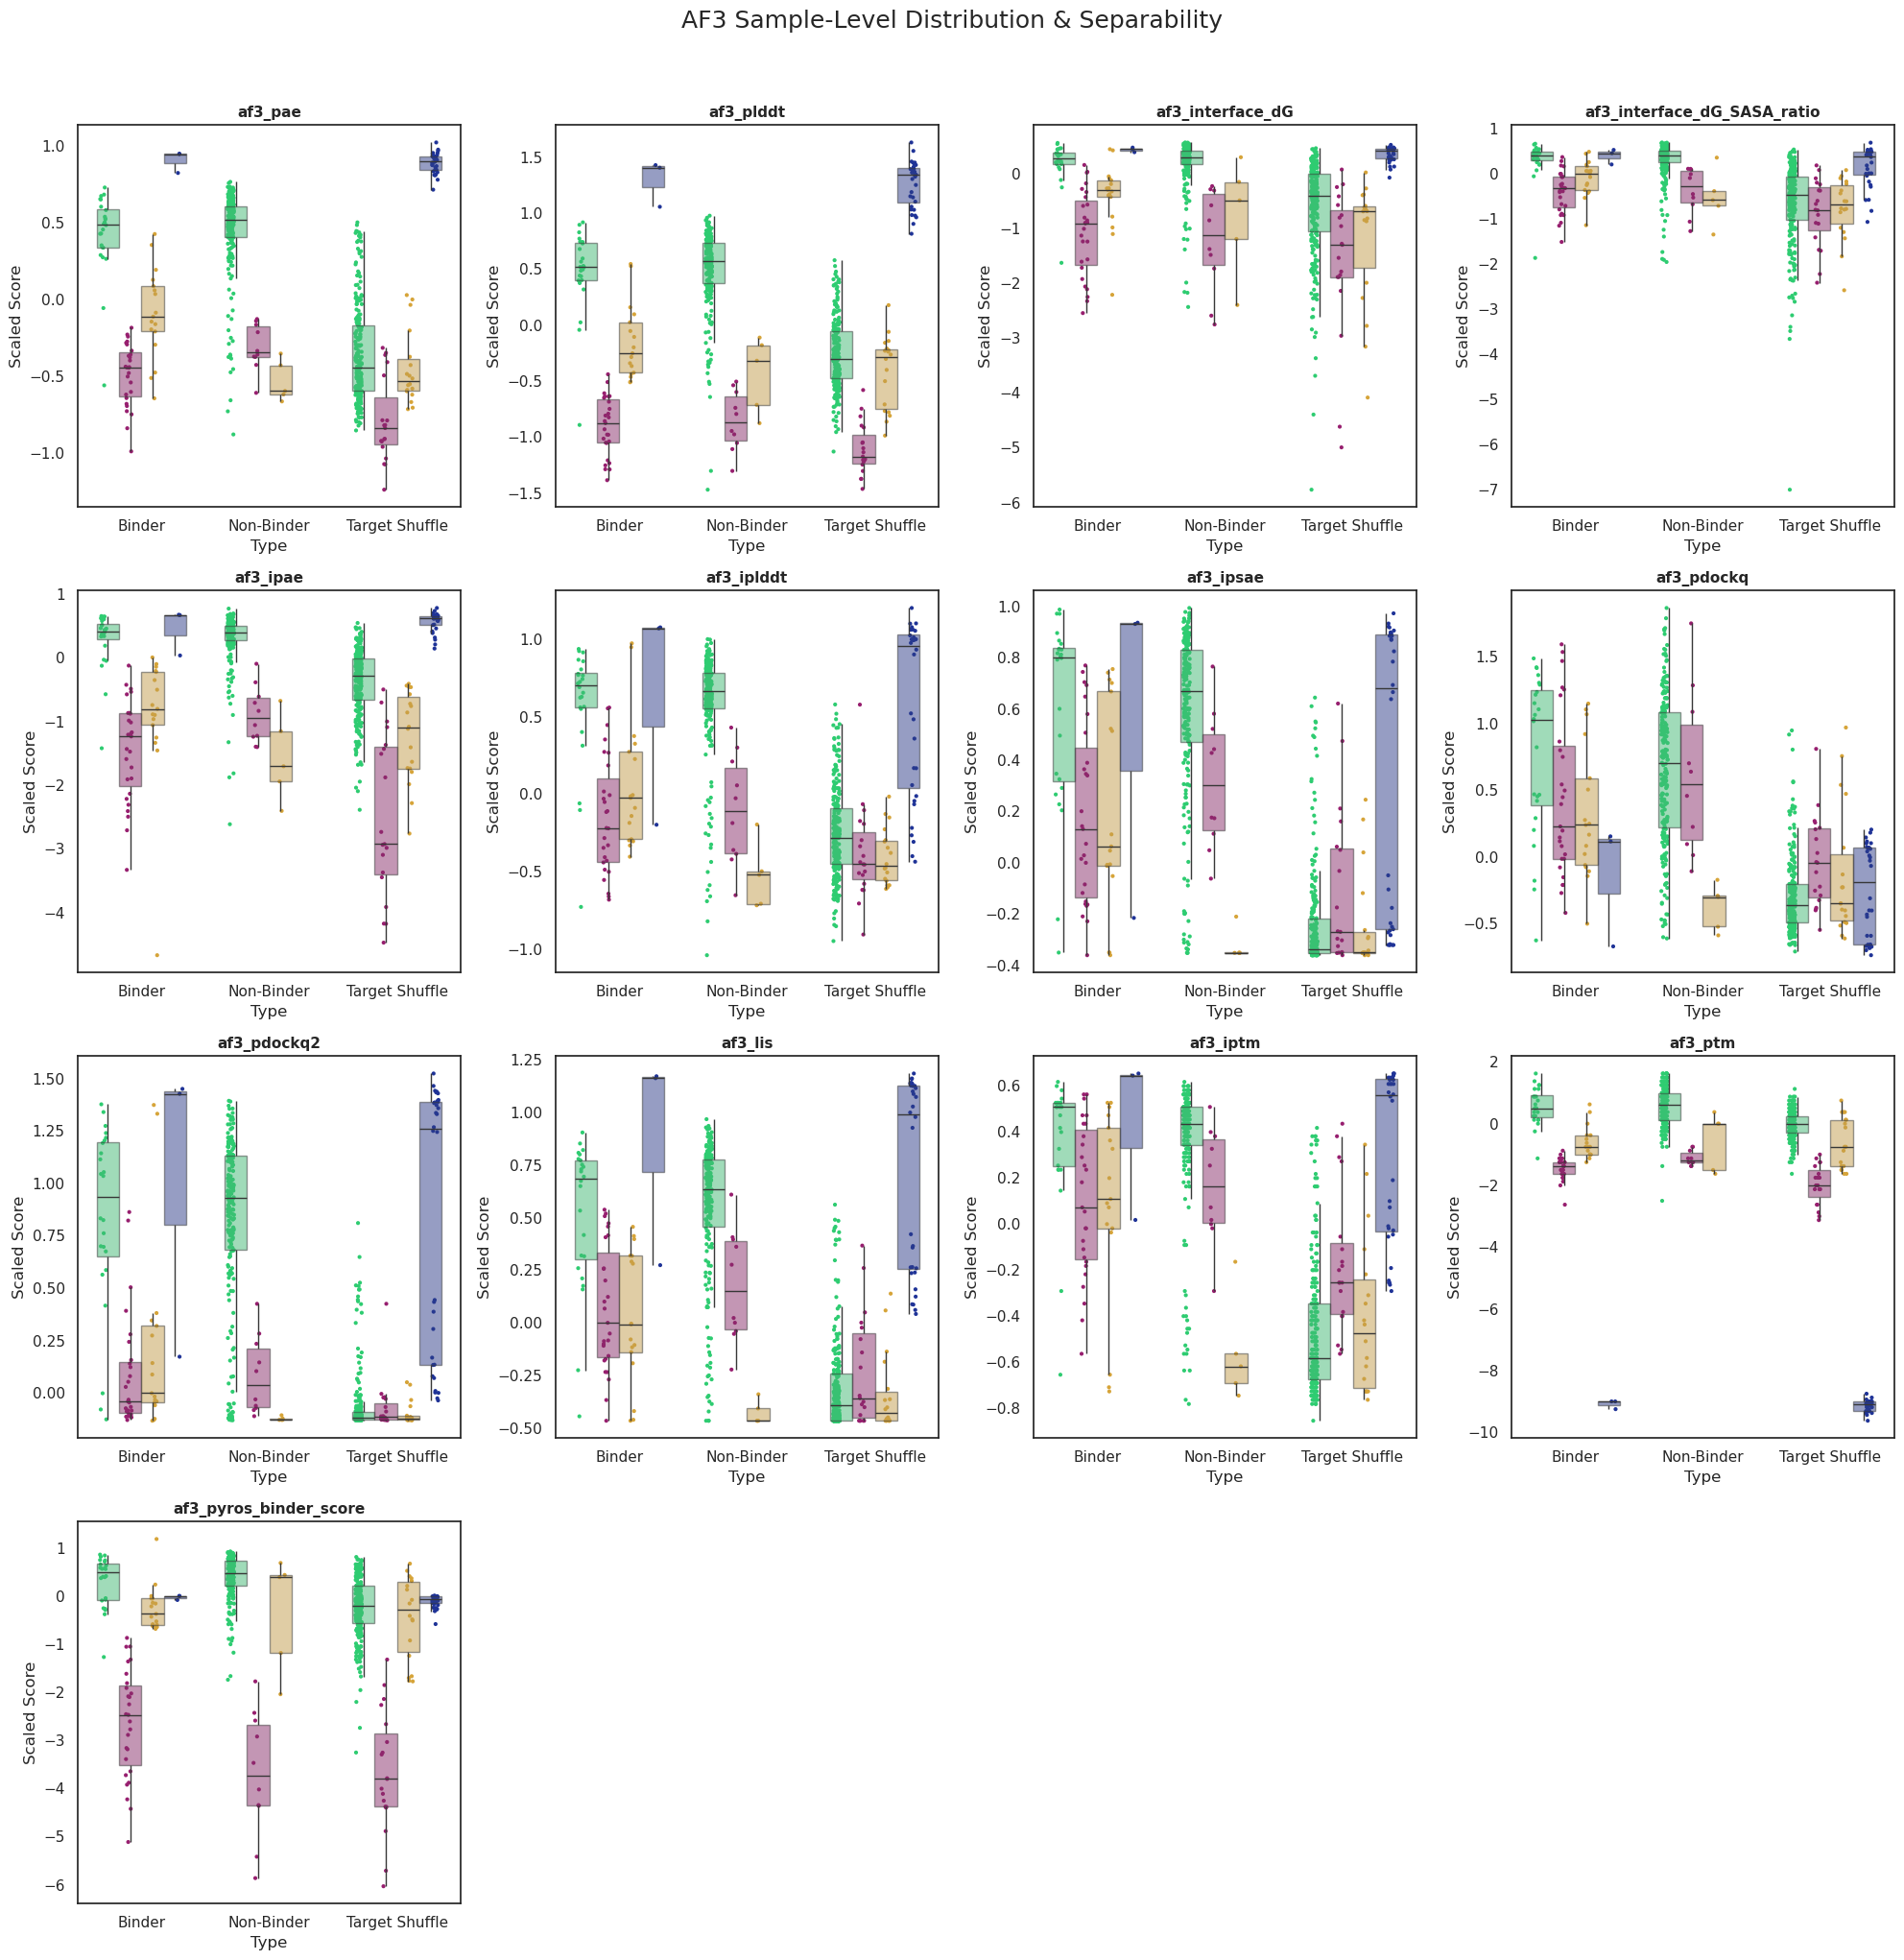

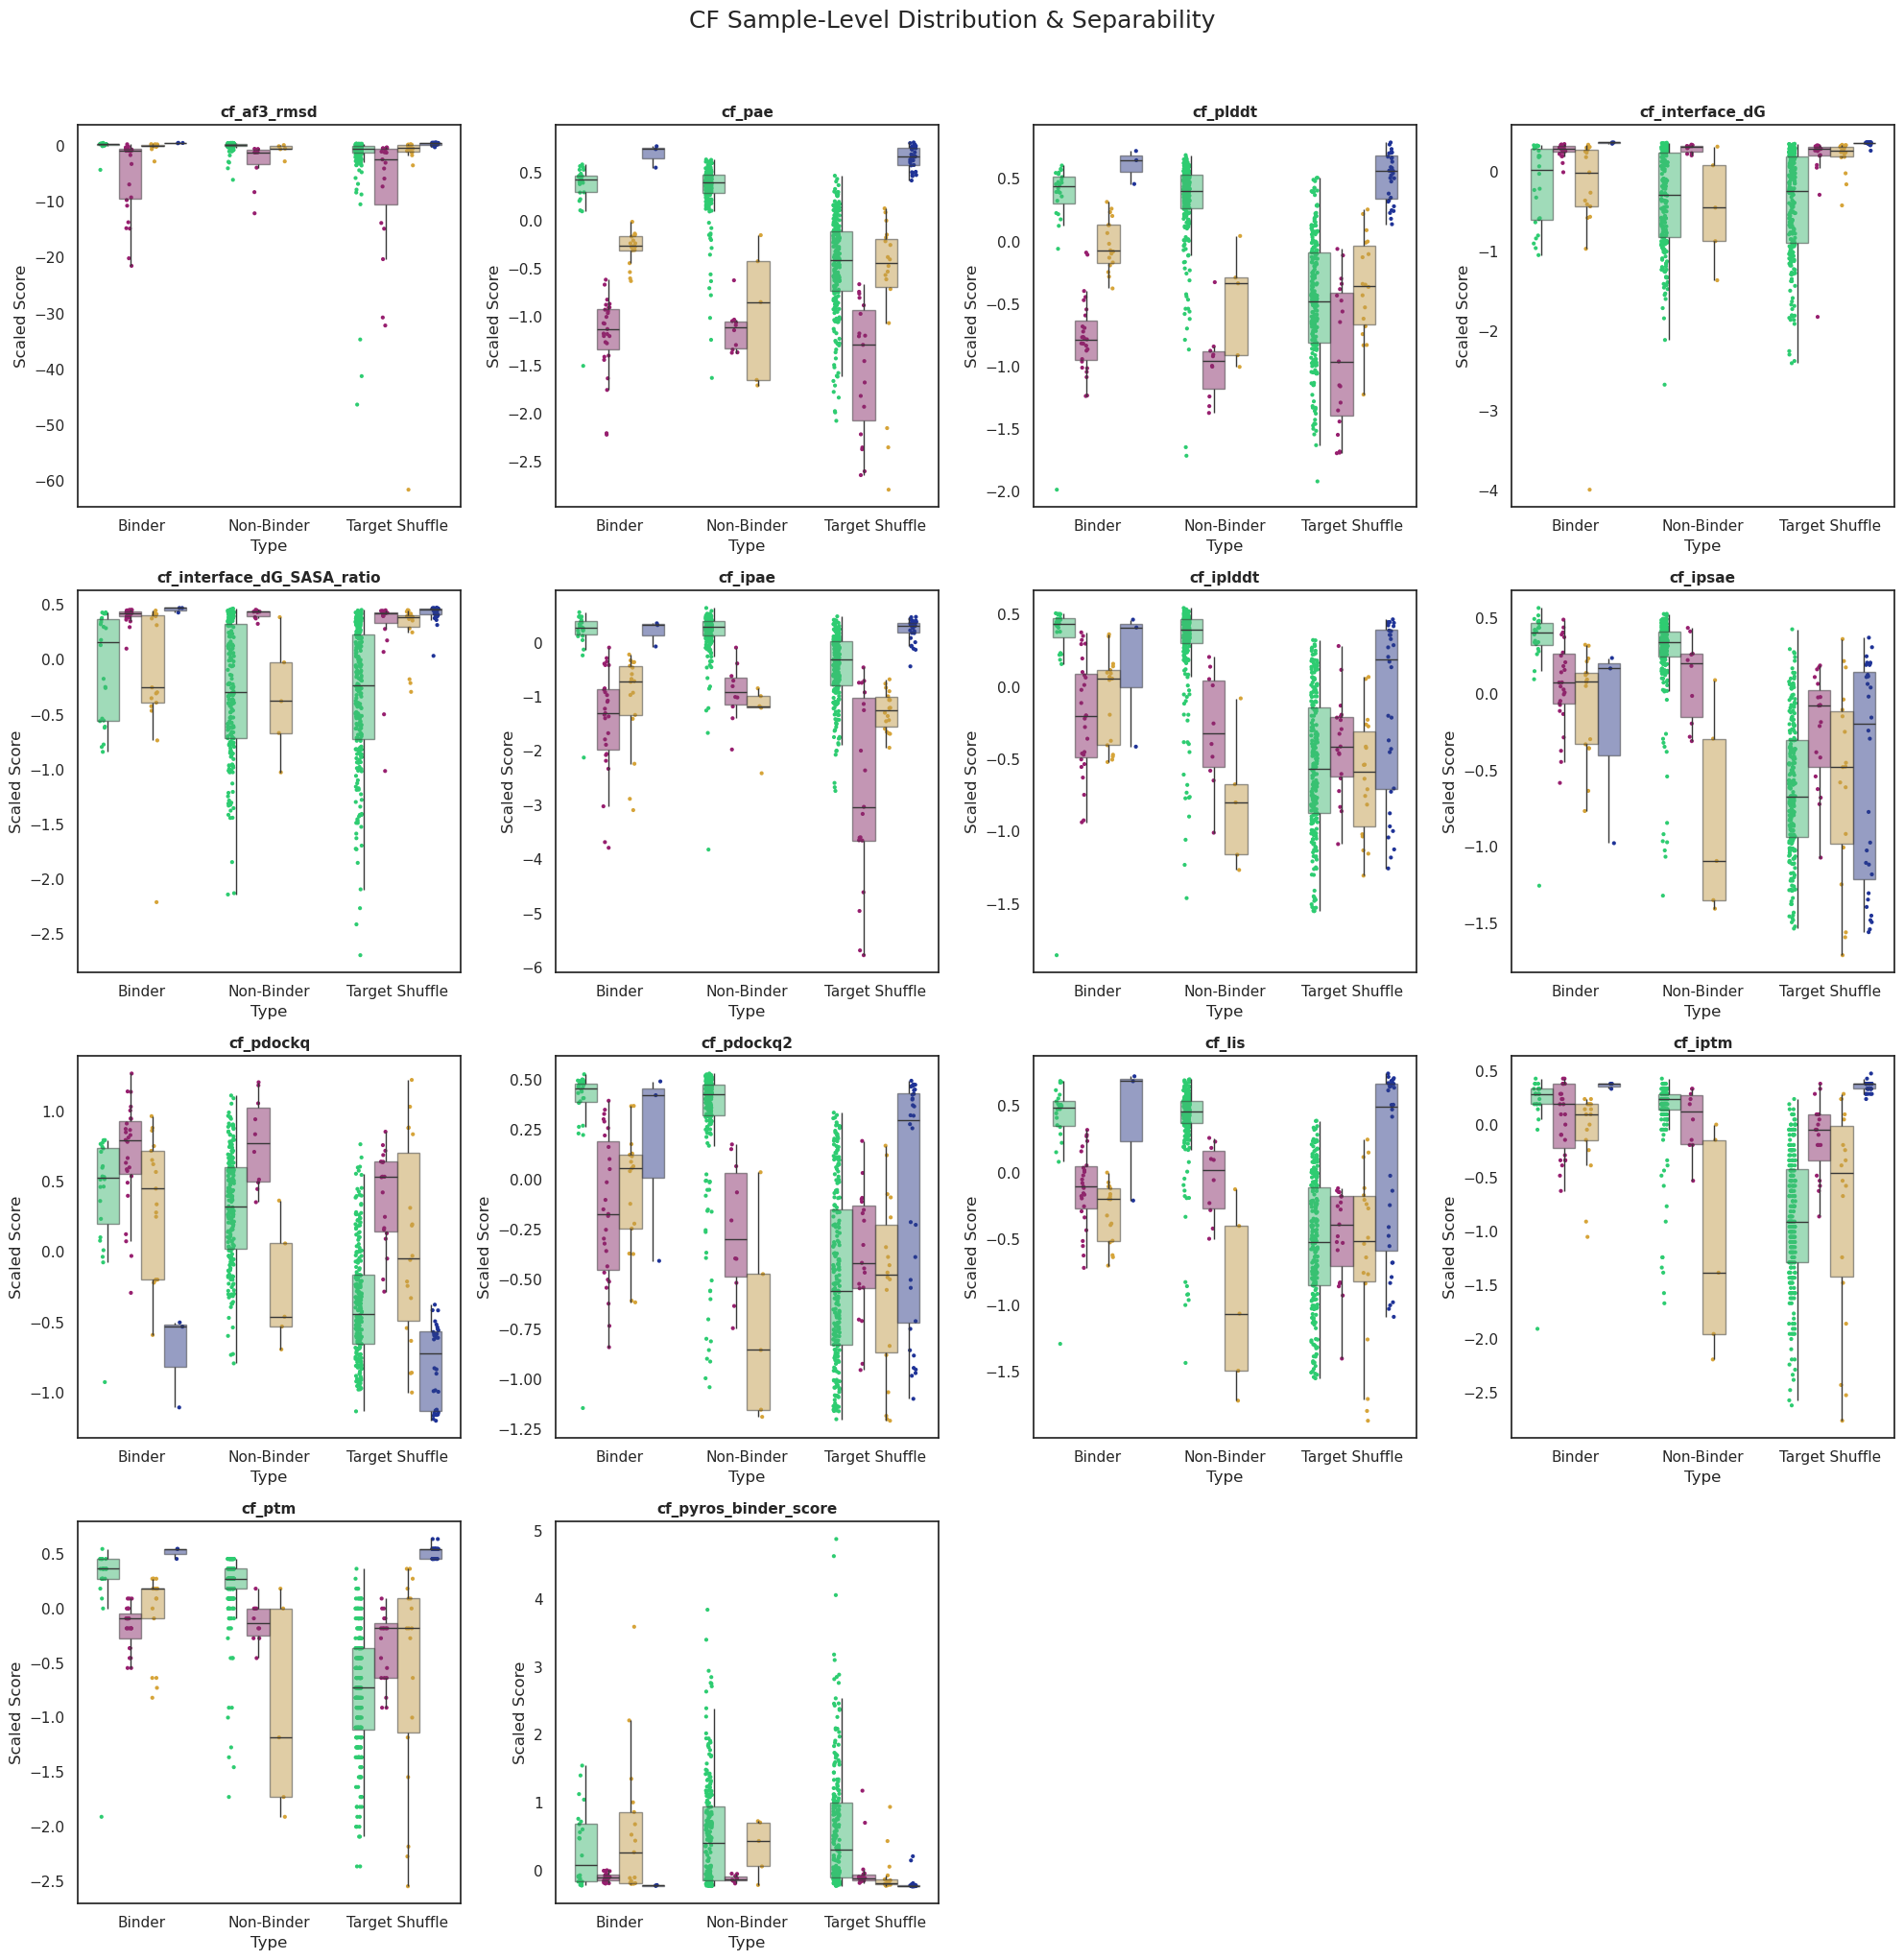

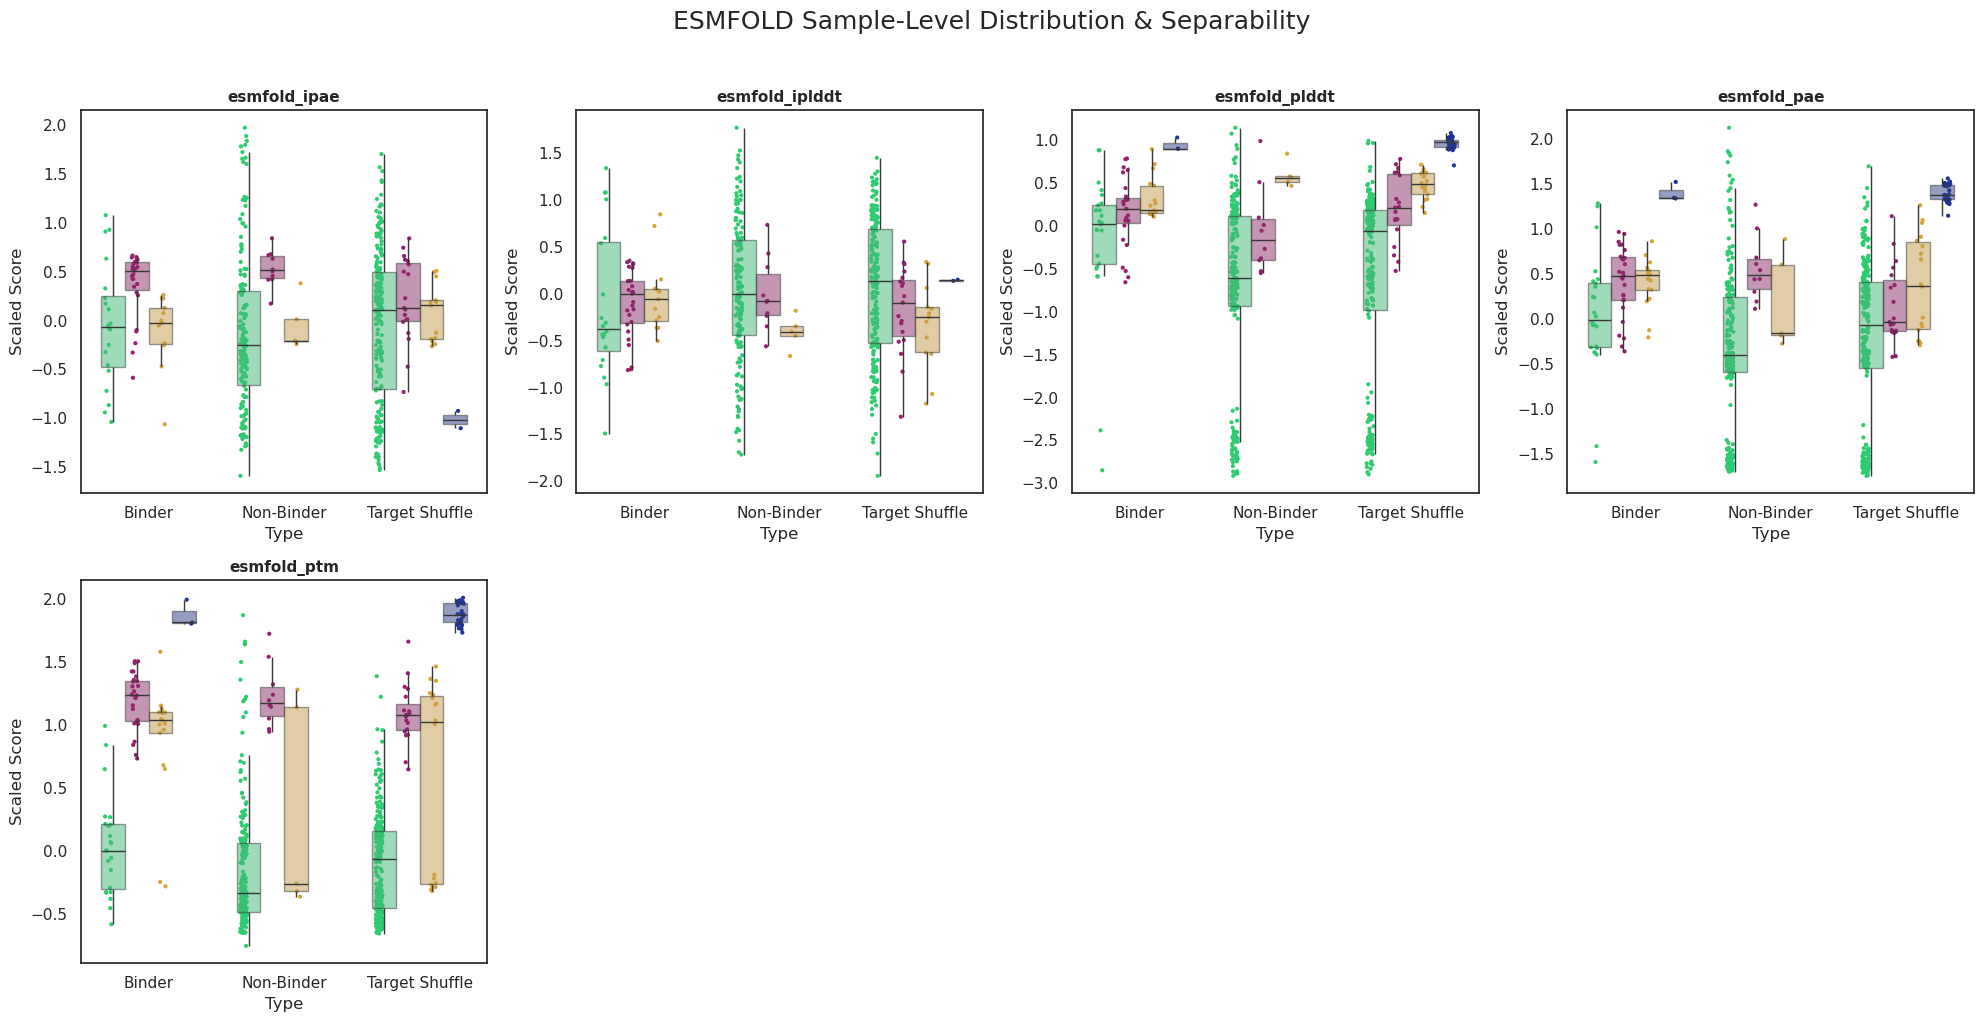

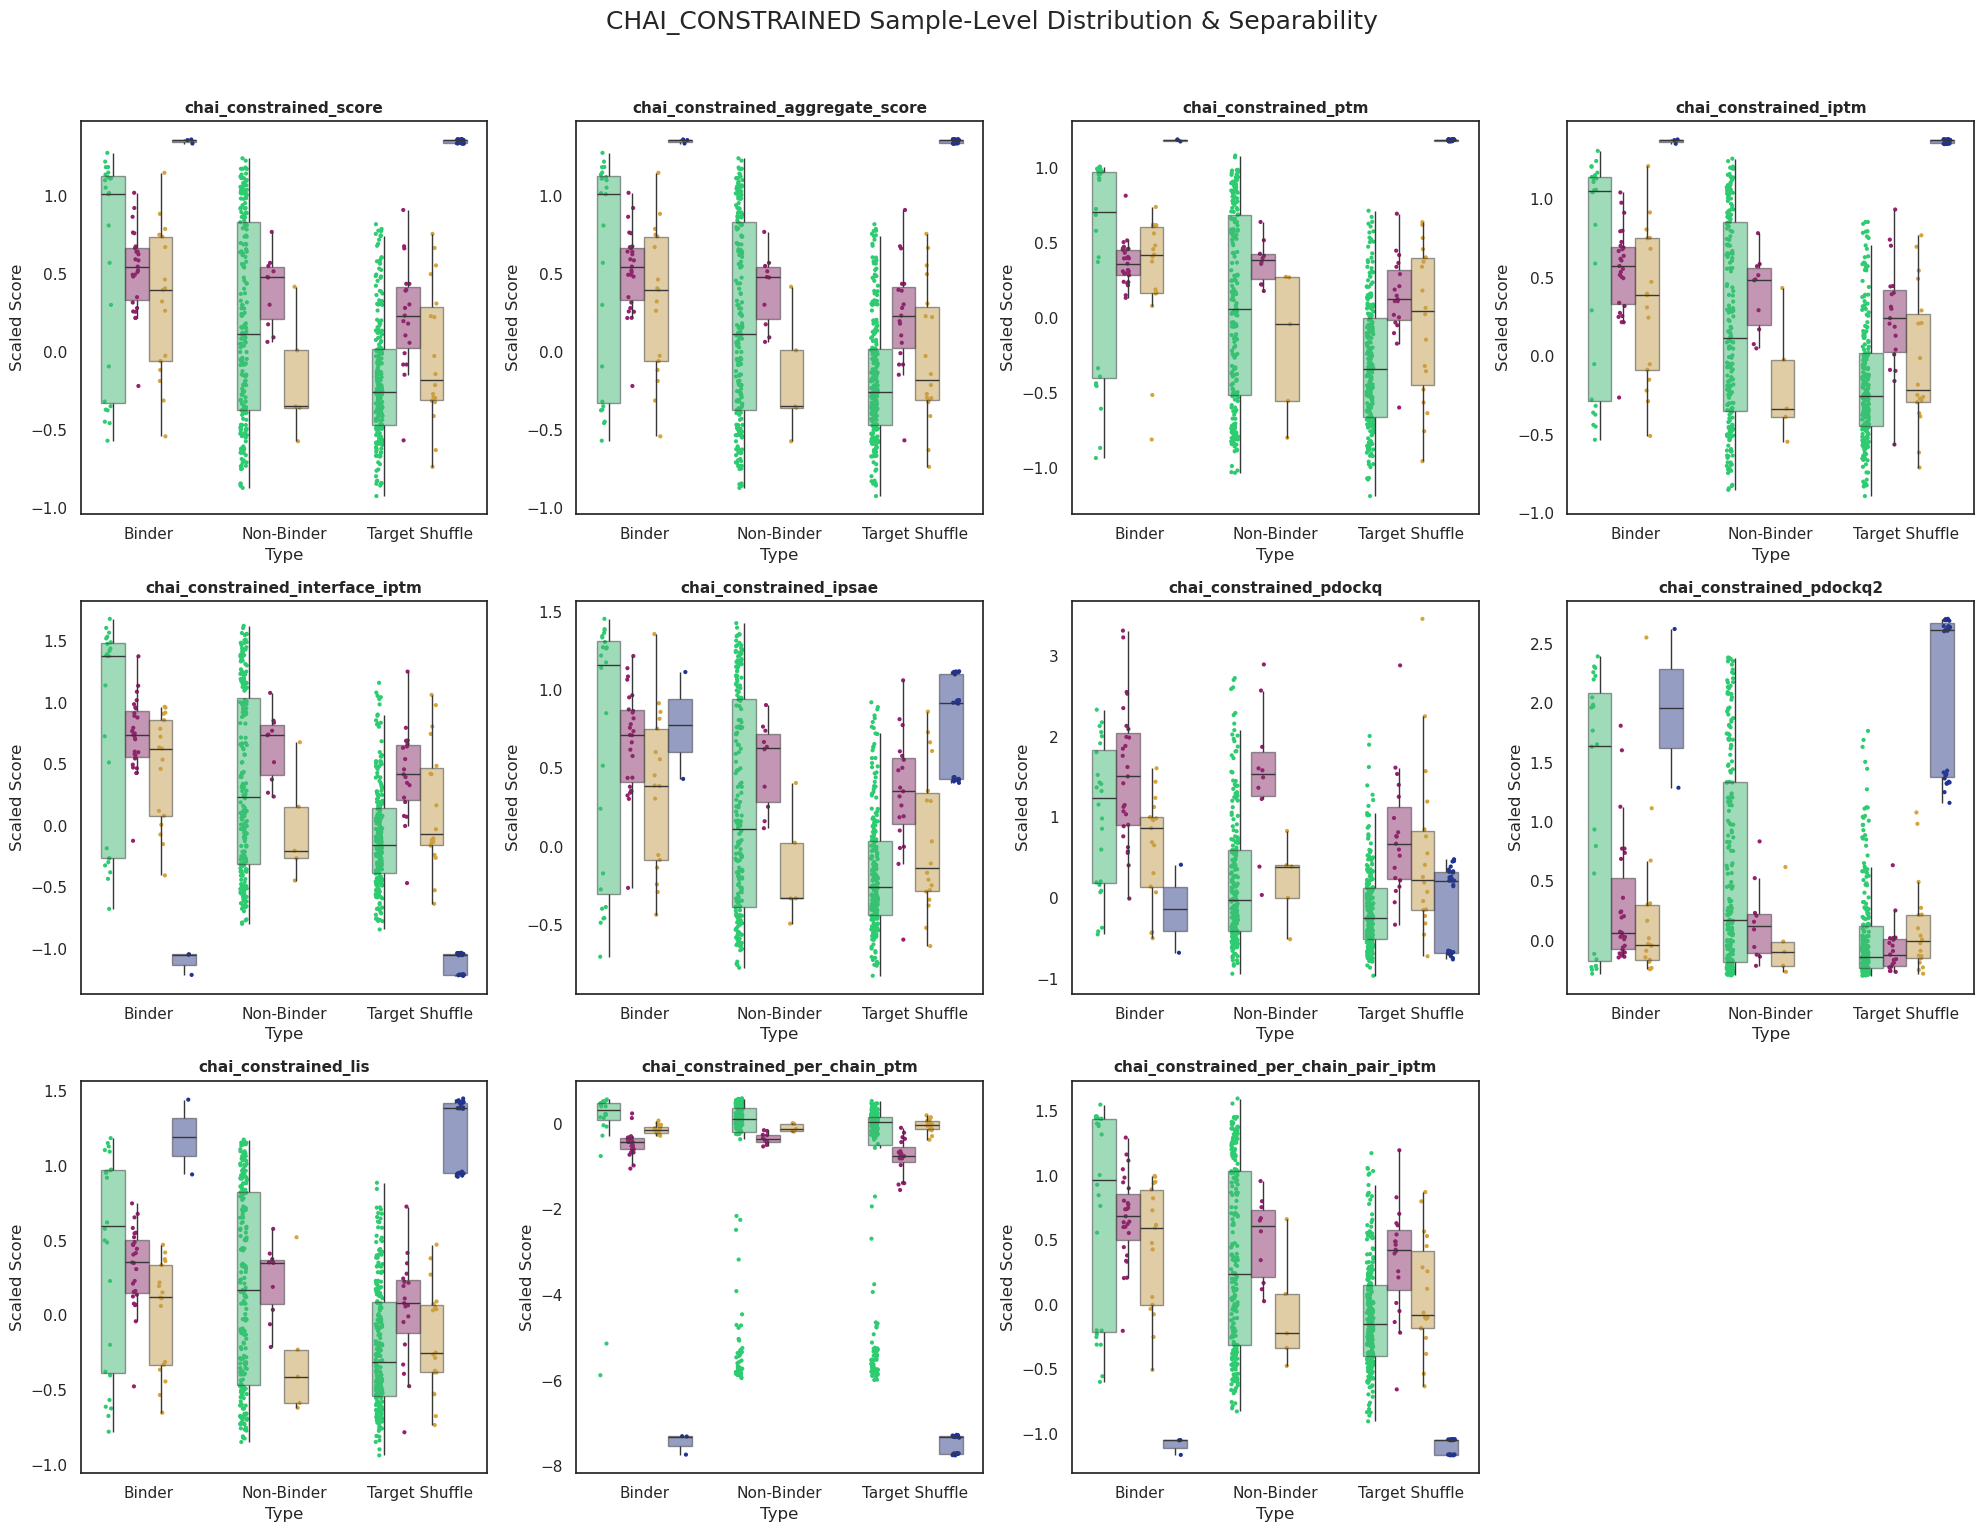

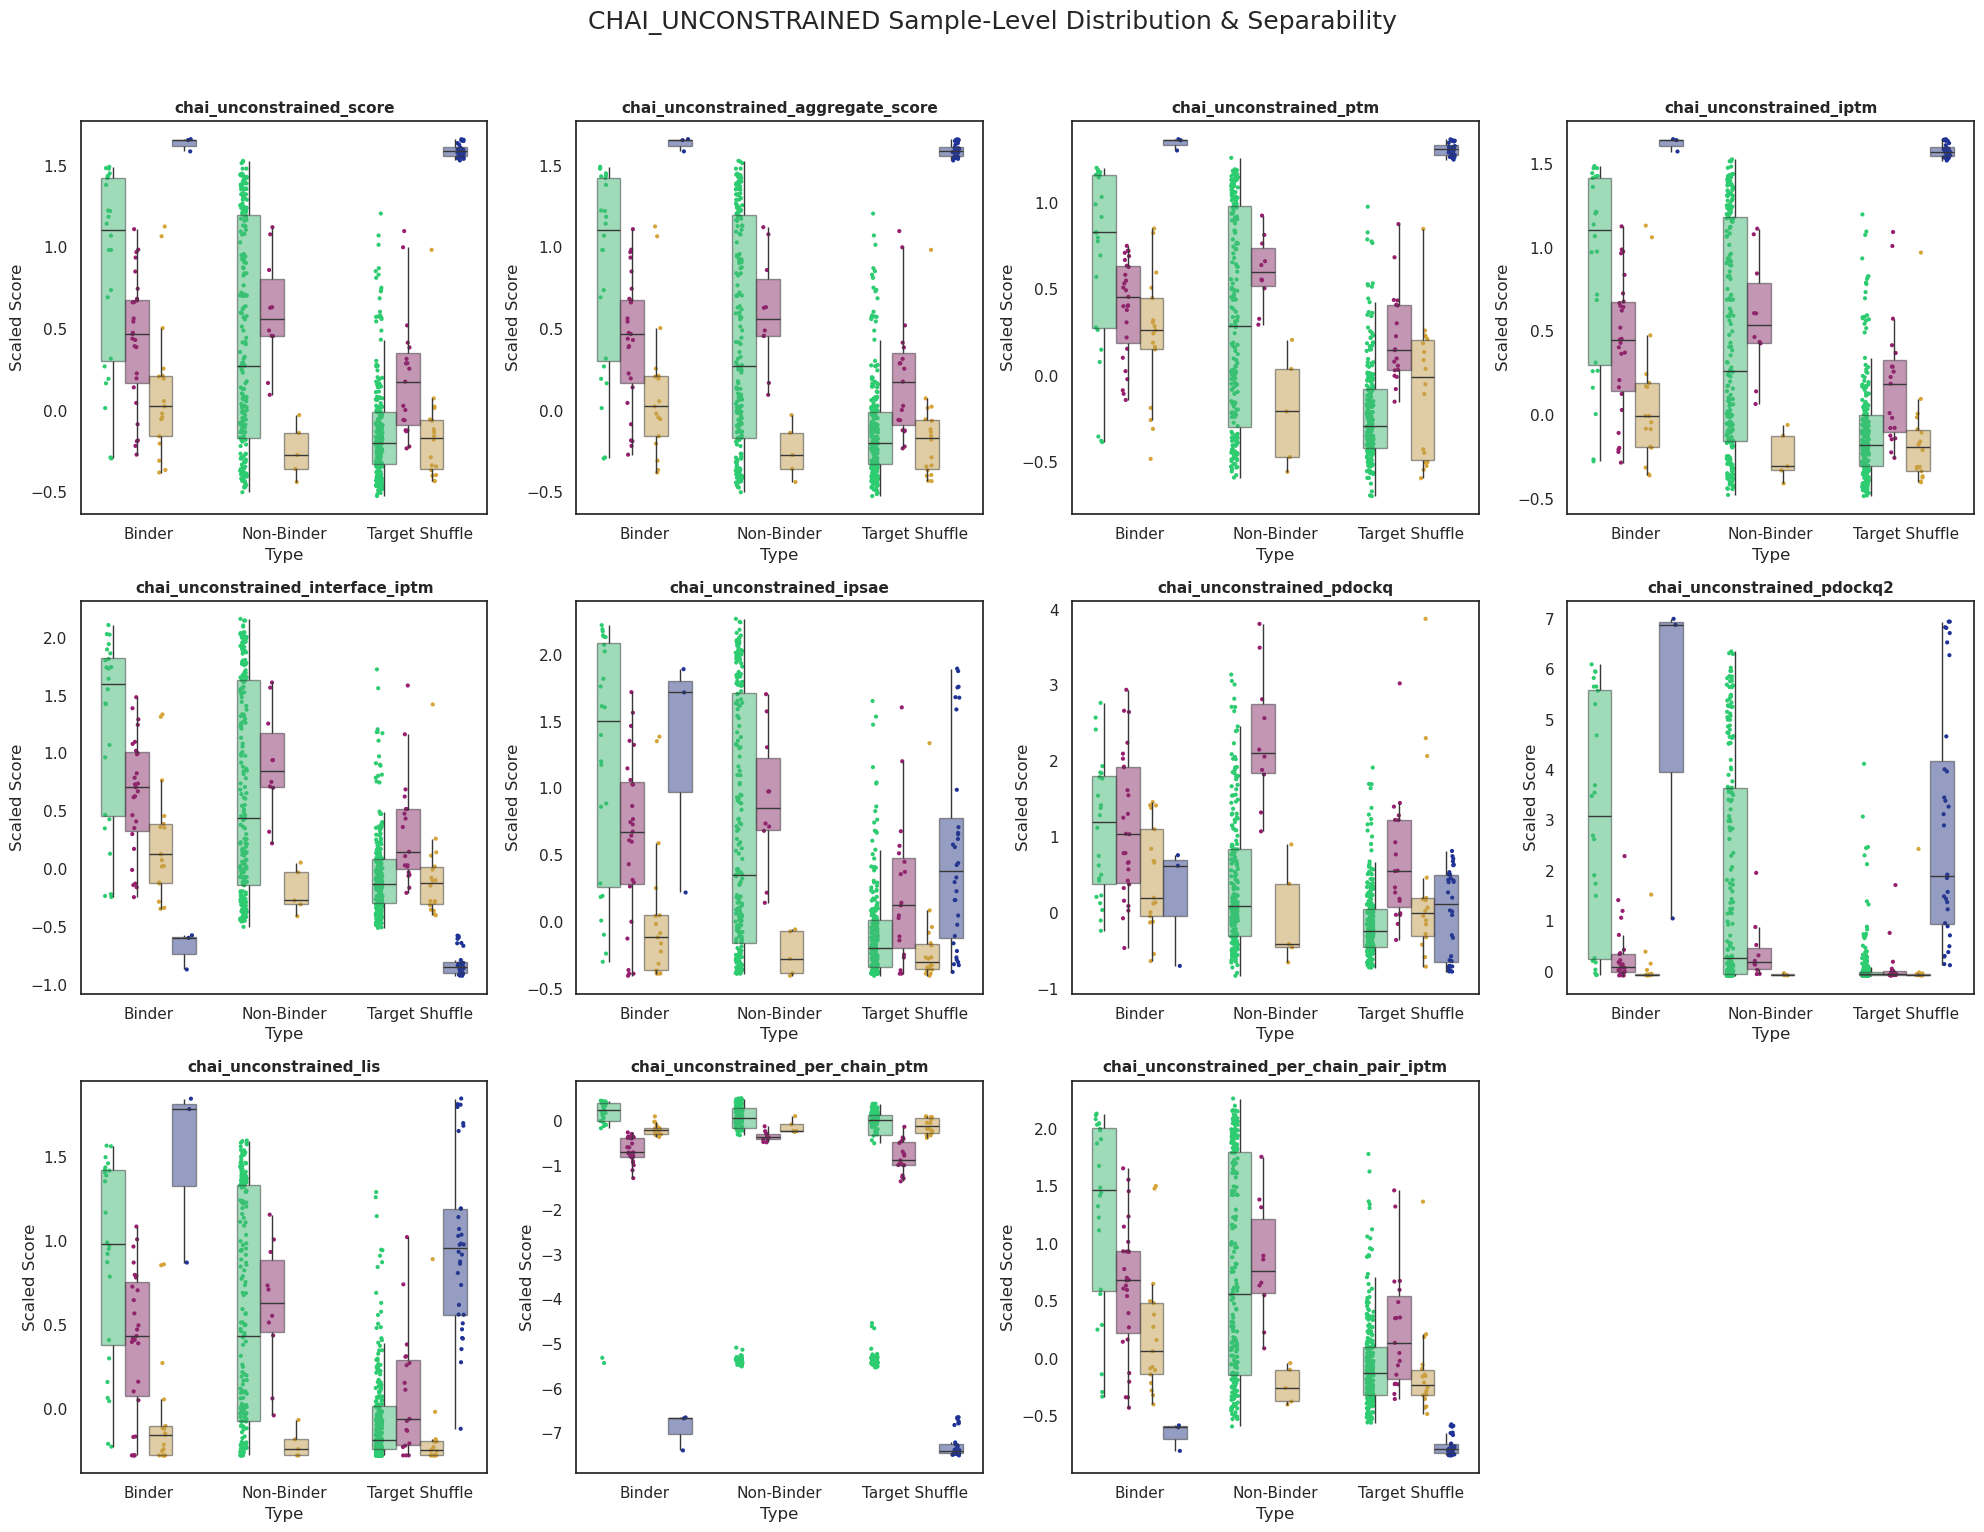

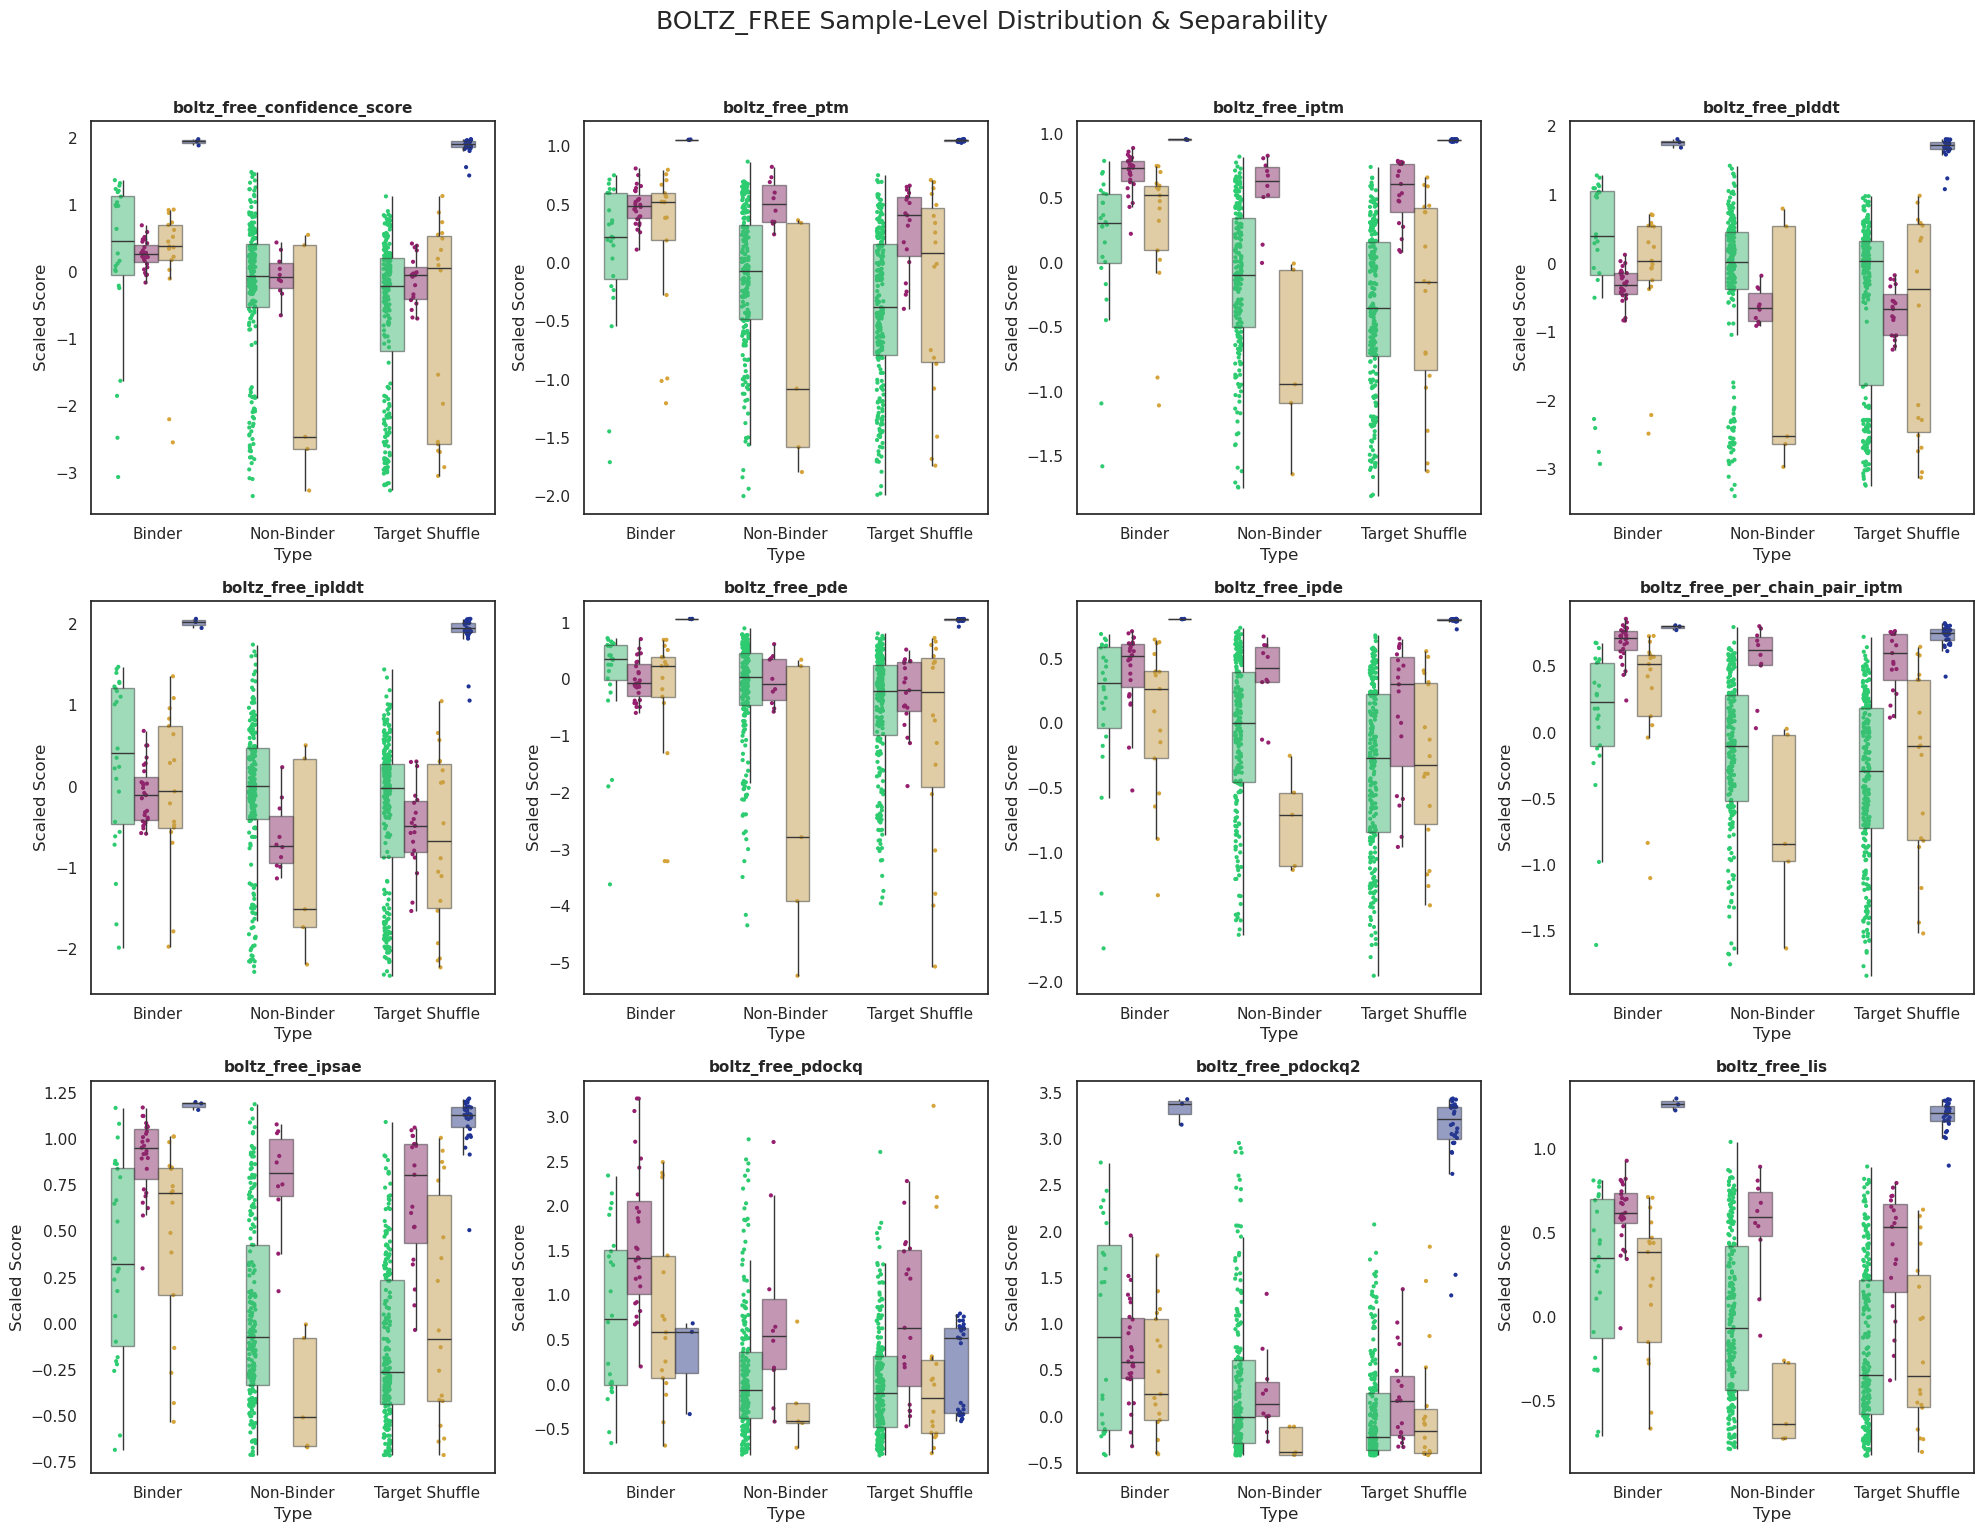

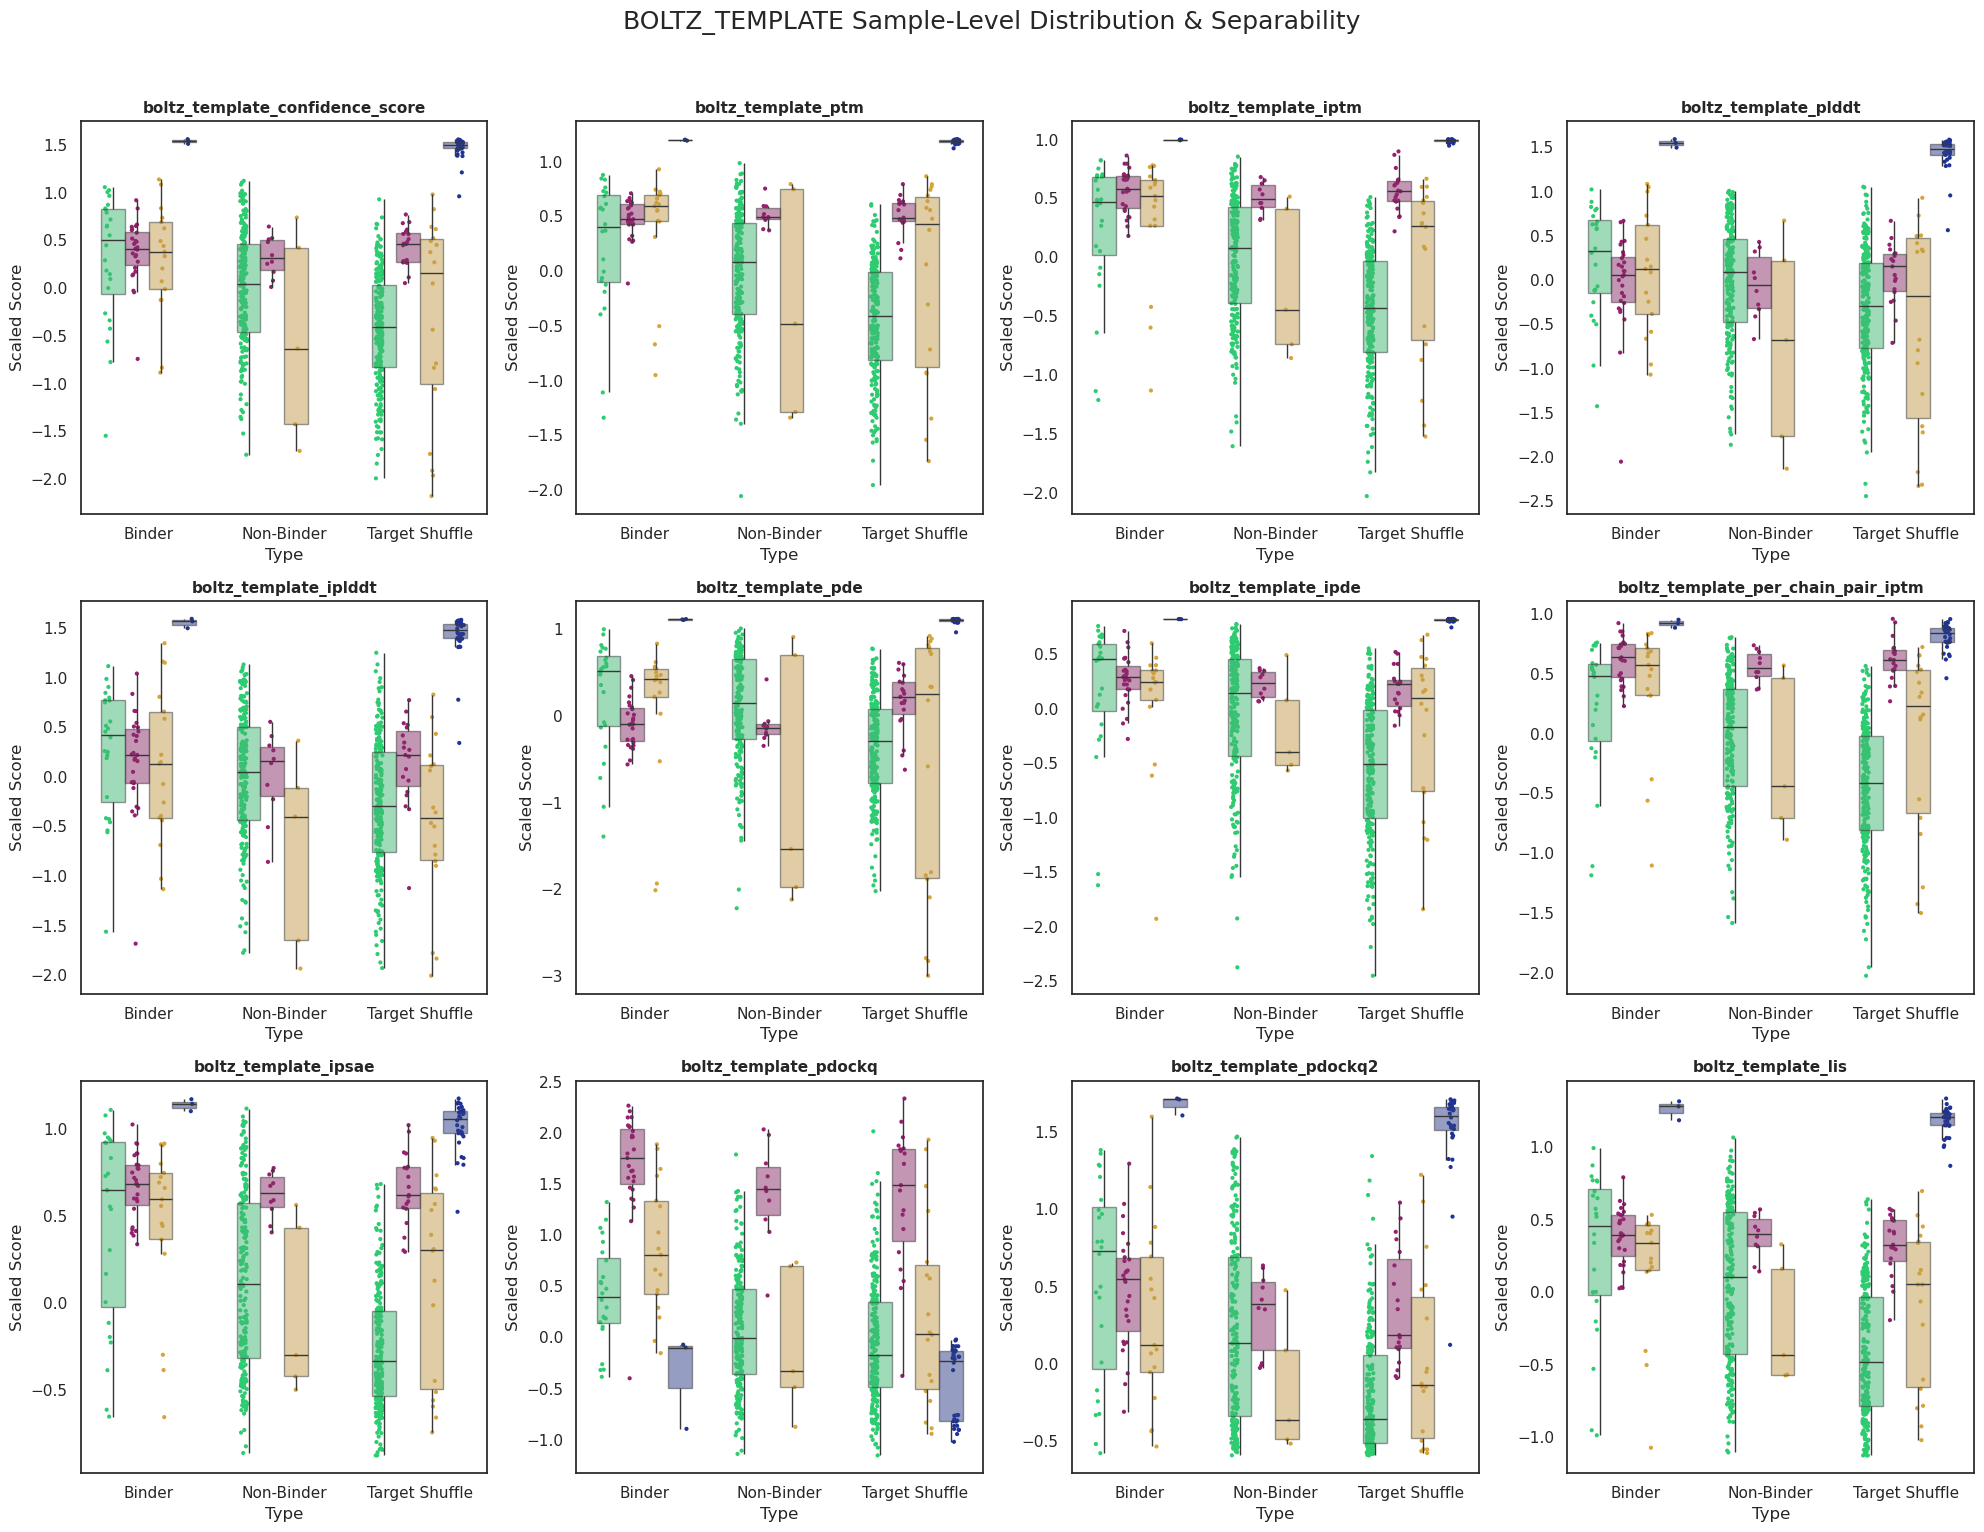

Finished generating separability scatterplots.


In [38]:
sns.set_theme(style='white')
x_order = ['Binder', 'Non-Binder', 'Target Shuffle']

for model, cols in model_groups.items():
    if not cols:
        continue

    model_long   = long_scores_df[long_scores_df['metric'].isin(cols)]
    valid_metrics = [
        c for c in cols
        if not model_long[model_long['metric'] == c]['value'].isna().all()
    ]
    if not valid_metrics:
        print(f"Skipping {model.upper()}: No valid numeric data.")
        continue

    n_cols_grid = 4
    n_rows = (len(valid_metrics) + n_cols_grid - 1) // n_cols_grid
    fig, axes = plt.subplots(n_rows, n_cols_grid, figsize=(20, 5 * n_rows))
    axes = np.atleast_1d(axes).flatten()

    for i, metric in enumerate(valid_metrics):
        ax = axes[i]
        plot_df = (
            model_long[model_long['metric'] == metric]
            .dropna(subset=['value'])
            .copy()
        )
        if plot_df.empty:
            continue

        hue_order = sorted(plot_df['source'].unique())

        sns.stripplot(
            data=plot_df, x='binder_type', y='value', order=x_order,
            hue='source', hue_order=hue_order,
            dodge=True, jitter=0.1, palette=colors_map,
            size=3, ax=ax, legend=False,
        )
        sns.boxplot(
            data=plot_df, x='binder_type', y='value', order=x_order,
            hue='source', hue_order=hue_order,
            dodge=True, showcaps=False, fill=True,
            palette=colors_map, ax=ax,
            width=0.7, zorder=10, showfliers=False, legend=False,
        )
        for artist in ax.patches:
            artist.set_alpha(0.5)

        ax.set_title(metric, fontsize=11, fontweight='bold')
        ax.set_xlabel('Type')
        ax.set_ylabel('Scaled Score')

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle(
        f'{model.upper()} Sample-Level Distribution & Separability',
        fontsize=18, y=1.02,
    )
    plt.tight_layout()
    save_path = OUTPUT_DIR / f'{model}_separability_scatter.png'
    plt.savefig(save_path, dpi=200, bbox_inches='tight')  # save BEFORE show
    plt.show()

print('Finished generating separability scatterplots.')

### 4c. Correlation Heatmap

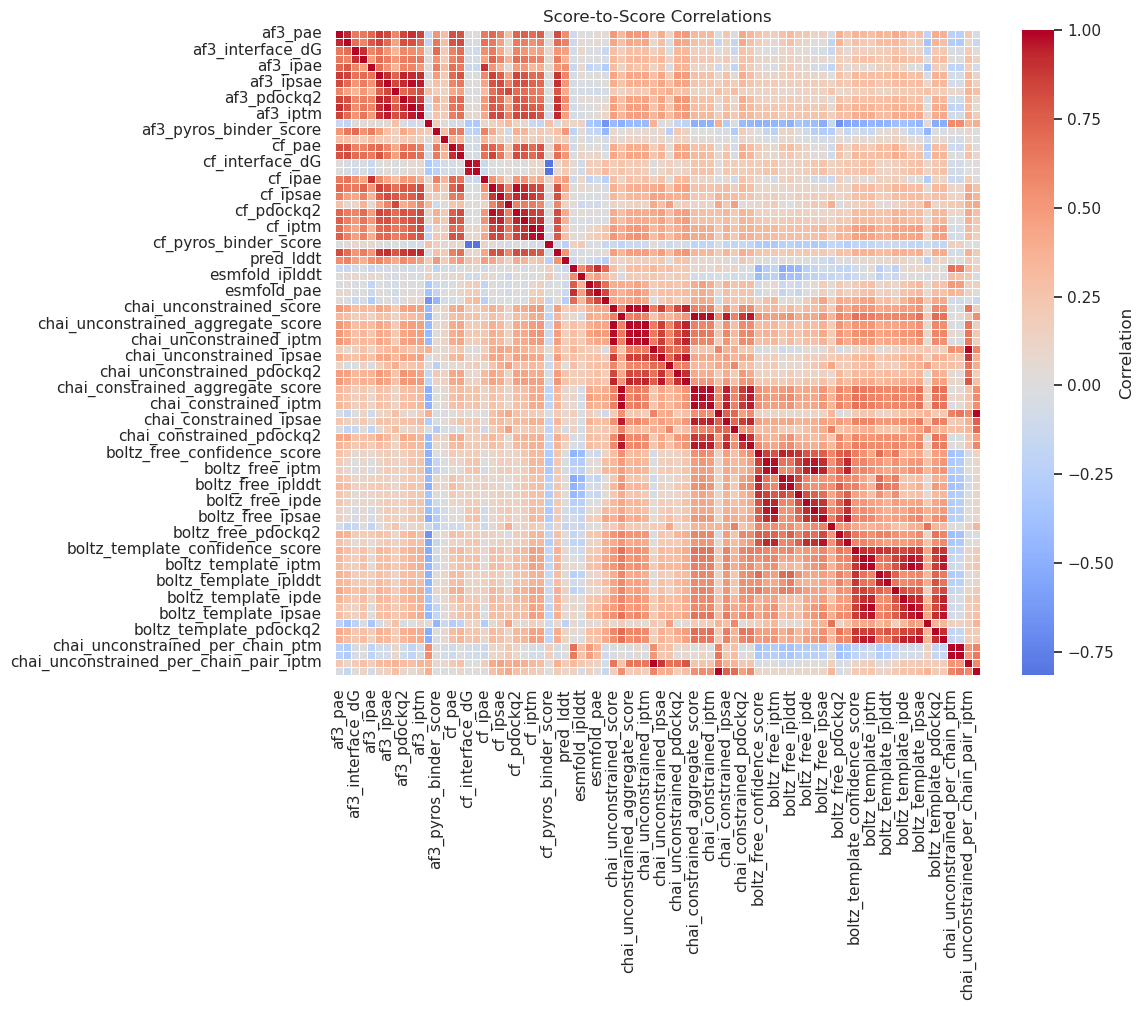

In [39]:
# Correlation matrix on the scaled (but not direction-aligned) data
numeric_df = scores_df_aligned[numeric_cols].dropna(axis=1, how='all')
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    correlation_matrix,
    annot=False, fmt='.2f', cmap='coolwarm',
    center=0, square=True, linewidths=0.5,
    cbar_kws={'label': 'Correlation'},
)
plt.title('Score-to-Score Correlations')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'score_correlation_heatmap.png',
            dpi=500, bbox_inches='tight')  # save BEFORE show
plt.show()